In [4]:
# Parameters and dataset builders
import os, json, io, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 14
BATCH = 32

# Resolve project root (notebook is at workspace root)
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'Color-Classification-CNN' / 'data'

# Original flat sources (adjusted relative paths)
BASE_DIR = str(DATA_ROOT / 'base_contents')      # flattened actual class folders
AUG_DIR = str(DATA_ROOT / 'augmented_contents')  # flattened augmented class folders

# New explicit split directories (created by split script)
# Switch to v5_split (19 classes)
TRAIN_SPLIT_DIR = str(DATA_ROOT / 'v5_split' / 'train')
VAL_SPLIT_DIR   = str(DATA_ROOT / 'v5_split' / 'val')

# Default labels list (used only if no split is loaded)
LABELS = [
    'beige_tan','black','blue','brown','cyan','gold','gray','green','lime',
    'magenta','navy','orange','pink','purple','red','silver','teal','white','yellow'
 ]

# Model/training hyperparams
BACKBONE = 'B0'
USE_IMAGENET = True
LR = 3e-4
EPOCHS = 8
DROPOUT = 0.3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DO_TRAIN = True

# Outputs
OUT_DIR = PROJECT_ROOT / 'Color-Classification-CNN' / 'export'
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUT = str(PROJECT_ROOT / 'Color-Classification-CNN' / 'models' / 'final' / 'color_model_effb0_19cls_aug_improved.keras')
REPORTS_DIR = PROJECT_ROOT / 'Color-Classification-CNN' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
LABELS_JSON = str(OUT_DIR / 'labels_19.json')

# Data augmentation (online)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# New: explicit loader using pre-split train/val directories (no validation_split)
def build_train_val_from_split(train_dir, val_dir, seed=SEED):
    base_train = keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='categorical',
        shuffle=True,
        seed=seed,
        image_size=(IMG_SIZE, IMG_SIZE),
        color_mode='rgb',
        batch_size=BATCH,
    )
    base_val = keras.utils.image_dataset_from_directory(
        val_dir,
        labels='inferred',
        label_mode='categorical',
        shuffle=False,
        seed=seed,
        image_size=(IMG_SIZE, IMG_SIZE),
        color_mode='rgb',
        batch_size=BATCH,
    )
    class_names = base_train.class_names
    assert class_names == base_val.class_names, f"Class mismatch: {class_names} vs {base_val.class_names}"
    def to_float(x,y):
        return tf.cast(x, tf.float32), y
    AUTOTUNE = tf.data.AUTOTUNE
    ds_train = base_train.map(to_float, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_val = base_val.map(to_float).prefetch(AUTOTUNE)
    return ds_train, ds_val, class_names

# Build datasets from explicit split if present; otherwise defer to legacy builder in next cell
print('Loading datasets from split directories if available...')
if os.path.isdir(TRAIN_SPLIT_DIR) and os.path.isdir(VAL_SPLIT_DIR):
    try:
        ds_train, ds_val, CLASS_NAMES = build_train_val_from_split(TRAIN_SPLIT_DIR, VAL_SPLIT_DIR)
        print('Split directories found. Classes:', CLASS_NAMES)
        # Persist labels used by this model
        try:
            with open(LABELS_JSON, 'w', encoding='utf-8') as f:
                json.dump(CLASS_NAMES, f, indent=2)
            print('Wrote labels to', LABELS_JSON)
        except Exception as e:
            print('Warning: could not write labels json:', e)
    except Exception as e:
        print('Failed to load split datasets; will fall back in next cell:', e)
else:
    print('Split directories not found; will construct datasets using BASE_DIR/AUG_DIR in next cell.')


Loading datasets from split directories if available...
Found 6260 files belonging to 19 classes.
Found 1140 files belonging to 19 classes.
Split directories found. Classes: ['beige_tan', 'black', 'blue', 'brown', 'cyan', 'gold', 'gray', 'green', 'lime', 'magenta', 'navy', 'orange', 'pink', 'purple', 'red', 'silver', 'teal', 'white', 'yellow']
Wrote labels to c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\export\labels_19.json


In [3]:
# Smoke run override: set EPOCHS=1 for a quick validation
EPOCHS = 1
print('Smoke run: EPOCHS set to', EPOCHS)


Smoke run: EPOCHS set to 1


In [5]:
# Dataset builders and augmentations
# Ensure channels_last without requiring extra import
tf.keras.backend.set_image_data_format('channels_last')

# Derive LABELS/NUM_CLASSES from the loaded split if available; fallback to file or default list
if 'CLASS_NAMES' in globals():
    LABELS = CLASS_NAMES
else:
    try:
        with open(LABELS_JSON, 'r') as f:
            LABELS = json.load(f)
    except Exception:
        LABELS = [
            "black","blue","cyan","dark_red","green","lime",
            "magenta","navy","orange","purple","red","teal","white","yellow"
        ]
NUM_CLASSES = len(LABELS)

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Strong yet safe aug: flip, rotation, translation, zoom, contrast, brightness-like via jitters
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1, 0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# Legacy builder retained for manual runs, but we prefer explicit split
# Only used if split datasets are not already constructed above

def build_train_val(base_dir, aug_dir=None, seed=SEED):
    ds_train_base = keras.utils.image_dataset_from_directory(
        base_dir,
        labels='inferred',
        label_mode='categorical',
        validation_split=0.1,
        subset='training',
        seed=seed,
        shuffle=True,
        image_size=(IMG_SIZE, IMG_SIZE),
        color_mode='rgb',
        batch_size=BATCH,
    )
    ds_val_local = keras.utils.image_dataset_from_directory(
        base_dir,
        labels='inferred',
        label_mode='categorical',
        validation_split=0.1,
        subset='validation',
        seed=seed,
        shuffle=False,
        image_size=(IMG_SIZE, IMG_SIZE),
        color_mode='rgb',
        batch_size=BATCH,
    )

    class_names = ds_train_base.class_names

    if aug_dir and os.path.isdir(aug_dir):
        files, labs = [], []
        for cls in class_names:
            cls_dir = os.path.join(aug_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fn in os.listdir(cls_dir):
                if os.path.splitext(fn)[1].lower() in ['.jpg','.jpeg','.png','.bmp']:
                    files.append(os.path.join(cls_dir, fn))
                    labs.append(class_names.index(cls))
        if files:
            aug_ds = tf.data.Dataset.from_tensor_slices((files, labs))
            def load_aug(path, label):
                img = tf.io.read_file(path)
                img = tf.image.decode_image(img, channels=3)
                img.set_shape([None, None, 3])
                img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method='bilinear')
                y = tf.one_hot(label, depth=NUM_CLASSES)
                return img, y
            aug_ds = aug_ds.shuffle(len(files), seed=seed).map(load_aug, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH)
            ds_train_local = ds_train_base.concatenate(aug_ds)
        else:
            ds_train_local = ds_train_base
    else:
        ds_train_local = ds_train_base

    # float32 cast; leave model to preprocess
    def to_float(x, y):
        return tf.cast(x, tf.float32), y

    AUTOTUNE = tf.data.AUTOTUNE
    ds_train_local = ds_train_local.map(to_float, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_val_local = ds_val_local.map(to_float).prefetch(AUTOTUNE)
    return ds_train_local, ds_val_local

# Only build legacy datasets if split ones are missing
if 'ds_train' not in globals() or 'ds_val' not in globals():
    ds_train, ds_val = build_train_val(BASE_DIR, AUG_DIR)
    print('Datasets loaded via BASE_DIR/AUG_DIR (validation_split=0.1).')
else:
    print('Using datasets from explicit split (TRAIN_SPLIT_DIR/VAL_SPLIT_DIR).')

print('Classes:', NUM_CLASSES, LABELS)


Using datasets from explicit split (TRAIN_SPLIT_DIR/VAL_SPLIT_DIR).
Classes: 19 ['beige_tan', 'black', 'blue', 'brown', 'cyan', 'gold', 'gray', 'green', 'lime', 'magenta', 'navy', 'orange', 'pink', 'purple', 'red', 'silver', 'teal', 'white', 'yellow']


In [34]:
# Model build (ImageNet optional)

def build_model(backbone=BACKBONE, dropout=DROPOUT, use_imagenet=USE_IMAGENET):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x = data_augmentation(inp)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    weights = 'imagenet' if use_imagenet else None
    try:
        if backbone == 'B2':
            base = tf.keras.applications.EfficientNetB2(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        elif backbone == 'B1':
            base = tf.keras.applications.EfficientNetB1(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        else:
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    except Exception as e:
        print('Failed to load ImageNet weights, falling back to random init:', e)
        if backbone == 'B2':
            base = tf.keras.applications.EfficientNetB2(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        elif backbone == 'B1':
            base = tf.keras.applications.EfficientNetB1(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        else:
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')

    x = base(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inp, out)
    return model

model = build_model()

# Optimizer: try AdamW, fallback to Adam
optimizer = None
for imp in [
    'tensorflow.keras.optimizers.experimental.AdamW',
    'tensorflow.keras.optimizers.AdamW',
]:
    try:
        parts = imp.split('.')
        module = __import__('.'.join(parts[:-1]), fromlist=[parts[-1]])
        AdamWCls = getattr(module, parts[-1])
        optimizer = AdamWCls(learning_rate=LR, weight_decay=WEIGHT_DECAY)
        break
    except Exception:
        continue
if optimizer is None:
    optimizer = keras.optimizers.Adam(learning_rate=LR)
    WEIGHT_DECAY = 0.0

loss = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
metrics = [keras.metrics.CategoricalAccuracy(name='acc')]

# Cosine restarts schedule (optional)
initial_lr = LR
schedule = keras.optimizers.schedules.CosineDecayRestarts(initial_lr, first_decay_steps=max(EPOCHS//3, 2))
try:
    optimizer.learning_rate = schedule
except Exception:
    pass

class ValF1Callback(keras.callbacks.Callback):
    def __init__(self, ds_val, patience=4, model_out=None):
        super().__init__()
        self.ds_val = ds_val
        self.patience = patience
        self.wait = 0
        self.best = -1.0
        self.model_out = model_out
    def on_epoch_end(self, epoch, logs=None):
        y_true = []
        y_pred = []
        for x, y in self.ds_val:
            p = self.model.predict(x, verbose=0)
            y_true.extend(np.argmax(y.numpy(), axis=1))
            y_pred.extend(np.argmax(p, axis=1))
        y_true_arr = np.array(y_true)
        y_pred_arr = np.array(y_pred)
        f1s = []
        classes = sorted(set(y_true_arr))
        for c in classes:
            tp = np.sum((y_true_arr==c)&(y_pred_arr==c))
            fp = np.sum((y_true_arr!=c)&(y_pred_arr==c))
            fn = np.sum((y_true_arr==c)&(y_pred_arr!=c))
            prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
            rec = tp/(tp+fn) if (tp+fn)>0 else 0.0
            f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s)) if f1s else 0.0
        print(f"\nEpoch {epoch+1}: val_macro_f1={macro_f1:.4f}")
        if macro_f1 > self.best + 1e-5:
            self.best = macro_f1
            self.wait = 0
            if self.model_out:
                self.model.save(self.model_out)
                print('Saved improved model ->', self.model_out)
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print('Early stopping on macro F1.')
                self.model.stop_training = True

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
print(model.summary())

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ValF1Callback(ds_val=ds_val, patience=4, model_out=MODEL_OUT)
]

if DO_TRAIN:
    history = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS, callbacks=callbacks)
    print('Best model saved (if improved) to', MODEL_OUT)
else:
    print('Training skipped (DO_TRAIN=False). Model built and compiled.')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19)             │        24,339 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,073,910 (15.54 MB)

 Trainable params: 4,031,887 (15.38 MB)

 Non-trainable params: 42,023 (164.16 KB)

None
    196/Unknown 974s 5s/step - acc: 0.6315 - loss: 1.6104

c:\Users\markr\Downloads\CNN Color Identifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_macro_f1=0.8247
Saved improved model -> c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 1036s 5s/step - acc: 0.8085 - loss: 1.1335 - val_acc: 0.8491 - val_loss: 1.0109 - learning_rate: 1.2436e-04
Saved improved model -> c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 1036s 5s/step - acc: 0.8085 - loss: 1.1335 - val_acc: 0.8491 - val_loss: 1.0109 - learning_rate: 1.2436e-04
Best model saved (if improved) to c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
Best model saved (if improved) to c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras


In [24]:
# Sanity check: single forward batch
sample_batch = next(iter(ds_train))
xb, yb = sample_batch
preds = model.predict(xb[:4], verbose=0)
print('Pred shape:', preds.shape, 'Sum first row:', preds[0].sum())
print('Classes predicted (first 4):', np.argmax(preds, axis=1))

Pred shape: (4, 14) Sum first row: 0.99999994
Classes predicted (first 4): [7 3 7 3]


In [4]:
# Logging: save model summary, config, and (if trained) history
import io, json, os
log_dir = "../../logs"
os.makedirs(log_dir, exist_ok=True)

# Model summary text (force UTF-8 on Windows)
summary_buf = io.StringIO()
model.summary(print_fn=lambda x: summary_buf.write(x + '\n'))
summary_text = summary_buf.getvalue()
with open(os.path.join(log_dir, 'improved_fine_tune_summary.txt'), 'w', encoding='utf-8') as f:
    f.write(summary_text)
print('Model summary written to logs/improved_fine_tune_summary.txt')

# Model architecture JSON
with open(os.path.join(log_dir, 'improved_fine_tune_architecture.json'), 'w', encoding='utf-8') as f:
    f.write(model.to_json())
print('Model architecture JSON written.')

# Training history (if run)
if 'history' in globals() and history is not None:
    hist_path = os.path.join(log_dir, 'improved_fine_tune_history.json')
    with open(hist_path, 'w', encoding='utf-8') as f:
        json.dump(history.history, f, indent=2, ensure_ascii=False)
    print('Training history written to', hist_path)
else:
    print('No training history variable present.')

# Save final weights snapshot (not just best)
final_weights_path = os.path.join(log_dir, 'improved_fine_tune_final_weights.keras')
model.save(final_weights_path)
print('Final weights snapshot saved to', final_weights_path)

NameError: name 'model' is not defined

In [ ]:
# Post-train paths and setup
import os, shutil
EXPORT_DIR = "../../export"  # keep existing export folder name
os.makedirs(EXPORT_DIR, exist_ok=True)

# Source model and labels from earlier cells
MODEL_FOR_EXPORT = MODEL_OUT
LABELS_SRC = LABELS_JSON
LABELS_EXPORTED = os.path.join(EXPORT_DIR, os.path.basename(LABELS_SRC))

# Copy labels into export folder
try:
    if os.path.abspath(LABELS_SRC) != os.path.abspath(LABELS_EXPORTED):
        shutil.copyfile(LABELS_SRC, LABELS_EXPORTED)
        print('Labels copied to', LABELS_EXPORTED)
    else:
        print('Labels already in export folder:', LABELS_EXPORTED)
except Exception as e:
    print('Warning: could not copy labels:', e)

# TFLite output paths
TFLITE_FP32 = os.path.join(EXPORT_DIR, "color_model_effb0_19cls_aug_improved_fp32.tflite")
TFLITE_FP16 = os.path.join(EXPORT_DIR, "color_model_effb0_19cls_aug_improved_fp16.tflite")

print('Model for export:', MODEL_FOR_EXPORT)
print('Export dir:', EXPORT_DIR)

Labels already in export folder: ../../export\labels_bw.json
Model for export: ../../models/final/color_model_effb0_aug_improved.keras
Export dir: ../../export


In [ ]:
# Export: Keras -> TFLite (FP32 + FP16)
import tensorflow as tf
from tensorflow import keras

# Load model
exp_model = keras.models.load_model(MODEL_FOR_EXPORT, compile=False)

# FP32 conversion
conv = tf.lite.TFLiteConverter.from_keras_model(exp_model)
tfl = conv.convert()
with open(TFLITE_FP32, 'wb') as f:
    f.write(tfl)
print('TFLite FP32 written to', TFLITE_FP32)

# FP16 conversion
conv = tf.lite.TFLiteConverter.from_keras_model(exp_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
tfl16 = conv.convert()
with open(TFLITE_FP16, 'wb') as f:
    f.write(tfl16)
print('TFLite FP16 written to', TFLITE_FP16)

INFO:tensorflow:Assets written to: C:\Users\markr\AppData\Local\Temp\tmpli_au978\assets


INFO:tensorflow:Assets written to: C:\Users\markr\AppData\Local\Temp\tmpli_au978\assets


Saved artifact at 'C:\Users\markr\AppData\Local\Temp\tmpli_au978'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  2607790909648: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2607790907920: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2607297213648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297214032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297211344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297212304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297211728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297213840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297212496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297214608: TensorSpec(shape=(), dtype=tf.resource, 

INFO:tensorflow:Assets written to: C:\Users\markr\AppData\Local\Temp\tmpxhrtpolu\assets


Saved artifact at 'C:\Users\markr\AppData\Local\Temp\tmpxhrtpolu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  2607790909648: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2607790907920: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2607297213648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297214032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297211344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297212304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297211728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297213840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297212496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607297214608: TensorSpec(shape=(), dtype=tf.resource, 

In [6]:
# Calibrate temperature on validation split
import json as _json
import numpy as _np

IMG_SIZE_CAL = (IMG_SIZE, IMG_SIZE)
BATCH_CAL = 64
TEMP_JSON = os.path.join(EXPORT_DIR, 'temperature_19.json')

# Build validation dataset from explicit VAL_SPLIT_DIR (no validation_split)
val_ds_cal = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=IMG_SIZE_CAL,
    batch_size=BATCH_CAL,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

cal_model = keras.models.load_model(MODEL_FOR_EXPORT, compile=False)

# Use log-prob trick as logits proxy
all_logp, all_y = [], []
for xb, yb in val_ds_cal:
    p = cal_model(xb, training=False).numpy()
    log_p = _np.log(_np.clip(p, 1e-12, 1.0))
    all_logp.append(log_p)
    all_y.append(yb.numpy())

logits = _np.concatenate(all_logp, axis=0)
y_true = _np.concatenate(all_y, axis=0)

# Temperature solver
def _softmax(z):
    z = z - _np.max(z, axis=1, keepdims=True)
    e = _np.exp(z)
    return e / _np.sum(e, axis=1, keepdims=True)

def _nll(probs, y_true):
    eps = 1e-12
    p = _np.clip(probs, eps, 1.0)
    return -float(_np.sum(y_true * _np.log(p))) / probs.shape[0]

def _calibrate_temperature(logits, y_true):
    T = 1.0
    for _ in range(200):
        probs = _softmax(logits / T)
        loss = _nll(probs, y_true)
        T_eps = T * 1.0001
        probs_eps = _softmax(logits / T_eps)
        loss_eps = _nll(probs_eps, y_true)
        g = (loss_eps - loss) / (T_eps - T + 1e-12)
        T = max(0.05, min(5.0, T - 0.1 * g))
        if abs(g) < 1e-5:
            break
    return float(T)

T_star = _calibrate_temperature(logits, y_true)
with open(TEMP_JSON, 'w', encoding='utf-8') as f:
    _json.dump({'temperature': T_star}, f, indent=2)
print('Calibrated temperature:', T_star, '->', TEMP_JSON)

Found 1140 files belonging to 19 classes.
Calibrated temperature: 0.6310031246494977 -> ../../export\temperature_19.json
Calibrated temperature: 0.6310031246494977 -> ../../export\temperature_19.json


In [7]:
# Confusion matrix (raw + normalized)
import numpy as _np, csv as _csv
from sklearn.metrics import confusion_matrix as _cm
CM_RAW_CSV = os.path.join(EXPORT_DIR, 'confusion_matrix_19.csv')
CM_NORM_CSV = os.path.join(EXPORT_DIR, 'confusion_matrix_19_norm.csv')

# Validation dataset from explicit VAL_SPLIT_DIR (int labels)
val_ds_int = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='int',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

cm_model = keras.models.load_model(MODEL_FOR_EXPORT, compile=False)

true_labels = []
pred_labels = []
for xb, yb in val_ds_int:
    p = cm_model(xb, training=False).numpy()
    pred = _np.argmax(p, axis=1)
    true_labels.extend(yb.numpy().tolist())
    pred_labels.extend(pred.tolist())

y_true_arr = _np.array(true_labels)
y_pred_arr = _np.array(pred_labels)
cm = _cm(y_true_arr, y_pred_arr, labels=list(range(NUM_CLASSES)))

with open(CM_RAW_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['class'] + LABELS)
    for i, row in enumerate(cm):
        w.writerow([LABELS[i]] + list(row))

# Normalized row-wise
with _np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm[_np.isnan(cm_norm)] = 0.0
with open(CM_NORM_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['class'] + LABELS)
    for i, row in enumerate(cm_norm):
        w.writerow([LABELS[i]] + list(row))

print('Confusion matrices written:', CM_RAW_CSV, CM_NORM_CSV)

Found 1140 files belonging to 19 classes.
Confusion matrices written: ../../export\confusion_matrix_19.csv ../../export\confusion_matrix_19_norm.csv
Confusion matrices written: ../../export\confusion_matrix_19.csv ../../export\confusion_matrix_19_norm.csv


In [ ]:
# Classification report (per-class + macro/weighted)
import os, csv as _csv, numpy as _np, tensorflow as tf
from tensorflow import keras

# Fallback if EXPORT_DIR not in globals (ensure path exists)
if 'EXPORT_DIR' not in globals():
    EXPORT_DIR = "../../export"
    os.makedirs(EXPORT_DIR, exist_ok=True)

CR_CSV = os.path.join(EXPORT_DIR, 'classification_report_19.csv')

val_ds_cat = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

rep_model = keras.models.load_model(MODEL_FOR_EXPORT, compile=False)

Y_true = []
Y_pred = []
for xb, yb in val_ds_cat:
    p = rep_model(xb, training=False).numpy()
    Y_true.append(yb.numpy())
    Y_pred.append(p)

y_true = _np.concatenate(Y_true, axis=0)
y_pred = _np.concatenate(Y_pred, axis=0)

y_true_idx = _np.argmax(y_true, axis=1)
y_pred_idx = _np.argmax(y_pred, axis=1)

rows = []
for i, name in enumerate(LABELS):
    tp = _np.sum((y_true_idx==i) & (y_pred_idx==i))
    fp = _np.sum((y_true_idx!=i) & (y_pred_idx==i))
    fn = _np.sum((y_true_idx==i) & (y_pred_idx!=i))
    support = _np.sum(y_true_idx==i)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    rows.append((name, prec, rec, f1, float(support)))

precs = [r[1] for r in rows]
recs  = [r[2] for r in rows]
f1s   = [r[3] for r in rows]
supps = [r[4] for r in rows]

total = sum(supps) if sum(supps)>0 else 1.0
macro = (float(_np.mean(precs)), float(_np.mean(recs)), float(_np.mean(f1s)), float(total))
weights = _np.array(supps)/total
weighted = (float(_np.sum(weights*precs)), float(_np.sum(weights*recs)), float(_np.sum(weights*f1s)), float(total))

with open(CR_CSV, 'w', newline='', encoding='utf-8') as f:
    w = _csv.writer(f)
    w.writerow(['class','precision','recall','f1','support'])
    for name, prec, rec, f1, sup in rows:
        w.writerow([name, prec, rec, f1, sup])
    w.writerow(['macro avg', macro[0], macro[1], macro[2], macro[3]])
    w.writerow(['weighted avg', weighted[0], weighted[1], weighted[2], weighted[3]])

print('Classification report written to', CR_CSV)
print('Macro F1:', macro[2], 'Weighted F1:', weighted[2])

Found 810 files belonging to 14 classes.
Classification report written to ../../export\classification_report_aug.csv
Macro F1: 0.9820823555607542 Weighted F1: 0.9814187391000413
Classification report written to ../../export\classification_report_aug.csv
Macro F1: 0.9820823555607542 Weighted F1: 0.9814187391000413


In [19]:
# Summary of exported artifacts
print('Export directory contents:')
for fn in sorted(os.listdir(EXPORT_DIR)):
    print(' -', fn)
print('Done pipeline.')

Export directory contents:
 - __pycache__
 - batch_score.py
 - classification_report_aug.csv
 - classification_report_bw_long.csv
 - color_model_effb0_aug_improved_fp16.tflite
 - color_model_effb0_aug_improved_fp32.tflite
 - color_model_effb0_bw_float32.tflite
 - color_model_effb0_bw_fp16.tflite
 - color_model_effb0_bw_long_float32.tflite
 - color_model_effb0_bw_long_fp16.tflite
 - color_model_effb0_bw_long_prod.keras
 - color_model_effb0_bw_prod.keras
 - color_model_effb0_float32.tflite
 - color_model_effb0_float32_20251105_123643.tflite
 - color_model_effb0_fp16.tflite
 - color_model_effb0_prod.keras
 - color_model_effb0_prod_20251105_123643.keras
 - confusion_matrix_aug.csv
 - confusion_matrix_aug_norm.csv
 - confusion_matrix_bw_long.csv
 - confusion_matrix_bw_long_normalized.csv
 - inference_helper.py
 - labels.json
 - labels_20251105_123643.json
 - labels_bw.json
 - saved_model
 - saved_model_20251105_123643
 - saved_model_bw
 - temperature.json
 - temperature_aug.json
 - temperat

History keys: ['acc', 'loss', 'val_acc', 'val_loss', 'learning_rate']


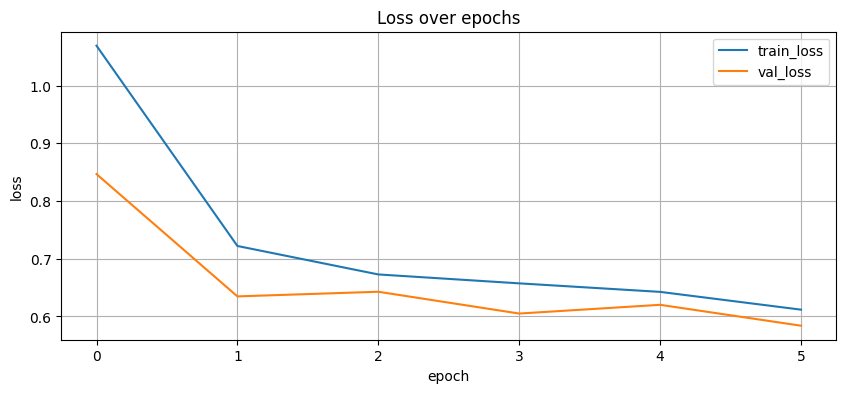

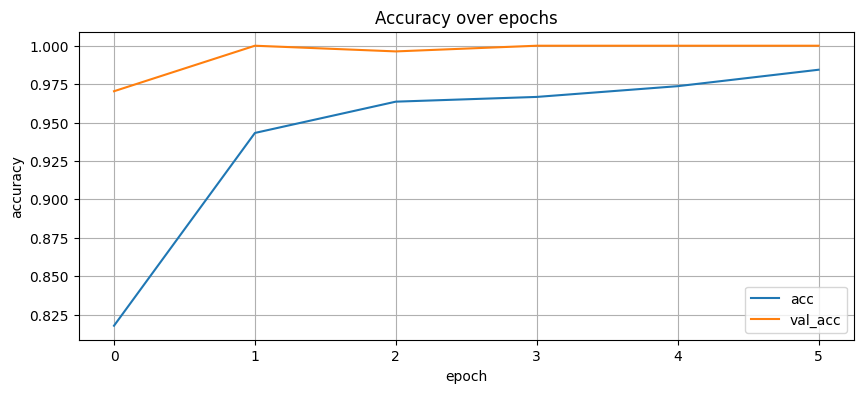

In [20]:
# Plot training history from logs
import json as _json
import matplotlib.pyplot as plt

HIST_LOG = '../../logs/improved_fine_tune_history.json'
if os.path.exists(HIST_LOG):
    with open(HIST_LOG, 'r', encoding='utf-8') as f:
        hist = _json.load(f)
    # Available keys typically include: loss, acc, val_loss, val_acc
    keys = list(hist.keys())
    print('History keys:', keys)
    plt.figure(figsize=(10,4))
    if 'loss' in hist:
        plt.plot(hist['loss'], label='train_loss')
    if 'val_loss' in hist:
        plt.plot(hist['val_loss'], label='val_loss')
    plt.title('Loss over epochs'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(10,4))
    # Try accuracy names
    acc_keys = [k for k in ['accuracy','acc','categorical_accuracy'] if k in hist]
    val_acc_keys = [k for k in ['val_accuracy','val_acc','val_categorical_accuracy'] if k in hist]
    if acc_keys:
        plt.plot(hist[acc_keys[0]], label=acc_keys[0])
    if val_acc_keys:
        plt.plot(hist[val_acc_keys[0]], label=val_acc_keys[0])
    plt.title('Accuracy over epochs'); plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.grid(True); plt.show()
else:
    print('No history log found at', HIST_LOG)

In [5]:
# Generate and save model architecture image
import os
import sys
from pathlib import Path
import tensorflow as tf
from tensorflow import keras

REPORTS_DIR = Path('../../reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Ensure Graphviz bin is on PATH (common Windows installs)
try:
    possible_bins = [
        r"C:\\Program Files\\Graphviz\\bin",
        r"C:\\Program Files (x86)\\Graphviz2.38\\bin",
        r"C:\\Program Files\\Graphviz2.38\\bin",
    ]
    for p in possible_bins:
        if os.path.isdir(p) and p not in os.environ.get('PATH',''):
            os.environ['PATH'] = p + os.pathsep + os.environ.get('PATH','')
except Exception:
    pass

# Resolve model to visualize
_model = None
if 'model' in globals() and isinstance(model, keras.Model):
    _model = model
else:
    try:
        _model = keras.models.load_model("../../models/final/color_model_effb0_aug_improved.keras", compile=False)
    except Exception as e:
        print('Failed to load saved model:', e)

out_png = REPORTS_DIR / 'architecture.png'
out_jpg = REPORTS_DIR / 'architecture.jpg'

ok = False
if _model is not None:
    # Try Graphviz-based plot first
    try:
        from tensorflow.keras.utils import plot_model
        try:
            plot_model(_model, to_file=str(out_png), show_shapes=True, show_dtype=False, expand_nested=False, dpi=144)
            ok = True
        except Exception as e:
            # Attempt lightweight install of dependencies then retry once
            print('plot_model failed, trying to ensure pydot/graphviz:', e)
            import subprocess
            try:
                subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pydot', 'graphviz'], stdout=subprocess.DEVNULL)
                plot_model(_model, to_file=str(out_png), show_shapes=True, show_dtype=False, expand_nested=False, dpi=144)
                ok = True
            except Exception as e2:
                print('Graphviz still not available; falling back to matplotlib diagram:', e2)
    except Exception as e:
        print('plot_model import failed; will draw fallback:', e)

# Fallback: simple layered diagram using matplotlib
if _model is not None and not ok:
    import matplotlib.pyplot as plt
    layers_info = []
    for lyr in _model.layers:
        try:
            out_shape = getattr(lyr, 'output_shape', None)
        except Exception:
            out_shape = None
        layers_info.append((lyr.name, lyr.__class__.__name__, str(out_shape)))

    fig, ax = plt.subplots(figsize=(12, max(4, len(layers_info)*0.35)))
    ax.axis('off')
    ax.set_title('Model Architecture (fallback)')
    y = 1.0
    dy = 1.0 / (len(layers_info) + 1)
    for name, typ, shp in layers_info:
        text = f"{name}  |  {typ}  |  {shp}"
        ax.text(0.02, y, text, fontsize=9, family='monospace', va='top')
        y -= dy
    fig.tight_layout()
    fig.savefig(out_png, dpi=180, bbox_inches='tight')
    plt.close(fig)
    ok = True

# Save JPEG alias if PNG exists
if ok and out_png.exists():
    try:
        from PIL import Image
        Image.open(out_png).convert('RGB').save(out_jpg, quality=92)
    except Exception as e:
        print('JPEG save skipped:', e)

print('Architecture image written:', str(out_png), '| exists =', out_png.exists())
print('JPEG alias:', str(out_jpg), '| exists =', out_jpg.exists())

Architecture image written: ..\..\reports\architecture.png | exists = True
JPEG alias: ..\..\reports\architecture.jpg | exists = True


In [18]:
# Clean diagram: move shapes inside nodes (HTML labels), remove edge labels — updated to 14 classes
from pathlib import Path
from graphviz import Digraph

REPORTS_DIR = Path('../../reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

png_path = REPORTS_DIR / 'architecture_block.png'
svg_path = REPORTS_DIR / 'architecture_block.svg'

G = Digraph('ColorCNN', format='png')
G.attr(rankdir='LR', splines='ortho', bgcolor='white', pad='0.25')
G.attr('node', fontname='Helvetica', shape='box3d', style='filled', color='#2c3e50', penwidth='1.3')
G.attr('edge', color='#7f8c8d', arrowsize='0.75', fontname='Helvetica', fontsize='10')

FEAT_GRAD = '#e8f1fb:#d6e6ff'
CLASS_GRAD = '#f4ecf7:#eadcf4'
AUG_GRAD = '#fff7e6:#ffe8bf'
INPUT_GRAD = '#eaf7ea:#d8f0d8'

# Helper: HTML label with title, micro, and shape (small gray)
def html_label(title, micro, shape):
    return f'<<B>{title}</B><BR/><FONT POINT-SIZE="10">{micro}</FONT><BR/><FONT POINT-SIZE="9" COLOR="#6b7280">{shape}</FONT>>'

# Input & Augmentation
input_shape = '224×224×3'
G.node('input', f'Input\n{input_shape}', fillcolor=INPUT_GRAD, gradientangle='90', color='#27ae60')
G.node('aug', 'Stage 0 — Augment', fillcolor=AUG_GRAD, gradientangle='90', color='#f39c12')
G.edge('input','aug')

# Stages: (id, title, micro conv label, shape)
stages = [
    ('stem', 'Stage 1 — Stem', 'k3/s2', '112×112×32'),
    ('s1',   'Stage 2 — MBConv1', 'k3/s1 e1×1', '112×112×16'),
    ('s2',   'Stage 3 — MBConv6', 'k3/s2 e6×2', '56×56×24'),
    ('s3',   'Stage 4 — MBConv6', 'k5/s2 e6×2', '28×28×40'),
    ('s4',   'Stage 5 — MBConv6', 'k3/s2 e6×3', '14×14×80'),
    ('s5',   'Stage 6 — MBConv6', 'k5/s1 e6×3', '14×14×112'),
    ('s6',   'Stage 7 — MBConv6', 'k5/s2 e6×4', '7×7×192'),
    ('s7',   'Stage 8 — MBConv6', 'k3/s1 e6×1', '7×7×320'),
    ('s8',   'Stage 9 — Conv 1×1', 'k1/s1', '7×7×1280'),
]

prev = 'aug'
for sid, title, micro, shape in stages:
    G.node(sid, label=html_label(title, micro, shape), fillcolor=FEAT_GRAD, gradientangle='90', color='#2980b9')
    G.edge(prev, sid)  # no edge labels to prevent overflow
    prev = sid

# Pooling and head with HTML labels
G.node('pool', label=html_label('Stage 10 — GlobalAvgPool', '—', '1×1×1280'), fillcolor=FEAT_GRAD, gradientangle='90', color='#2980b9')
G.edge('s8','pool')

G.node('head', label=html_label('Stage 11 — Head', 'Dropout 0.3 + Dense 14', '1×1×1280 → 14'), fillcolor=CLASS_GRAD, gradientangle='90', color='#8e44ad')
G.edge('pool','head')

G.attr('node', shape='ellipse', style='filled', color='#27ae60', fillcolor='#eaf7ea')
G.node('out', 'Stage 12 — Softmax\n14 Classes')
G.edge('head','out')

# Legend
with G.subgraph(name='cluster_leg') as L:
    L.attr(label='Legend', fontsize='11', color='#bdc3c7')
    L.attr('node', shape='box', style='filled', fontname='Helvetica', penwidth='0.8')
    L.node('leg_feat', 'Feature Blocks', fillcolor='#e8f1fb', color='#2980b9')
    L.node('leg_cls', 'Classification', fillcolor='#f4ecf7', color='#8e44ad')
    L.node('leg_aug', 'Augmentation', fillcolor='#fff7e6', color='#f39c12')
    L.node('leg_codes', 'Node: Title (bold), micro conv, shape (small gray).', fillcolor='#fdfdfd', color='#bdc3c7')

png_bytes = G.pipe(format='png')
with open(png_path, 'wb') as f:
    f.write(png_bytes)
svg_bytes = G.pipe(format='svg')
with open(svg_path, 'wb') as f:
    f.write(svg_bytes)

print('Cleaned 14-class diagram written:', str(png_path), 'and', str(svg_path))

Cleaned 14-class diagram written: ..\..\reports\architecture_block.png and ..\..\reports\architecture_block.svg


Flat diagram saved: ..\..\reports\architecture_14class_flat.png
SVG: ..\..\reports\architecture_14class_flat.svg
Letter: ..\..\reports\architecture_14class_flat_letter.png
Dataset samples saved: ..\..\reports\dataset_samples.png and ..\..\reports\dataset_samples_letter.png
Dataset samples saved: ..\..\reports\dataset_samples.png and ..\..\reports\dataset_samples_letter.png


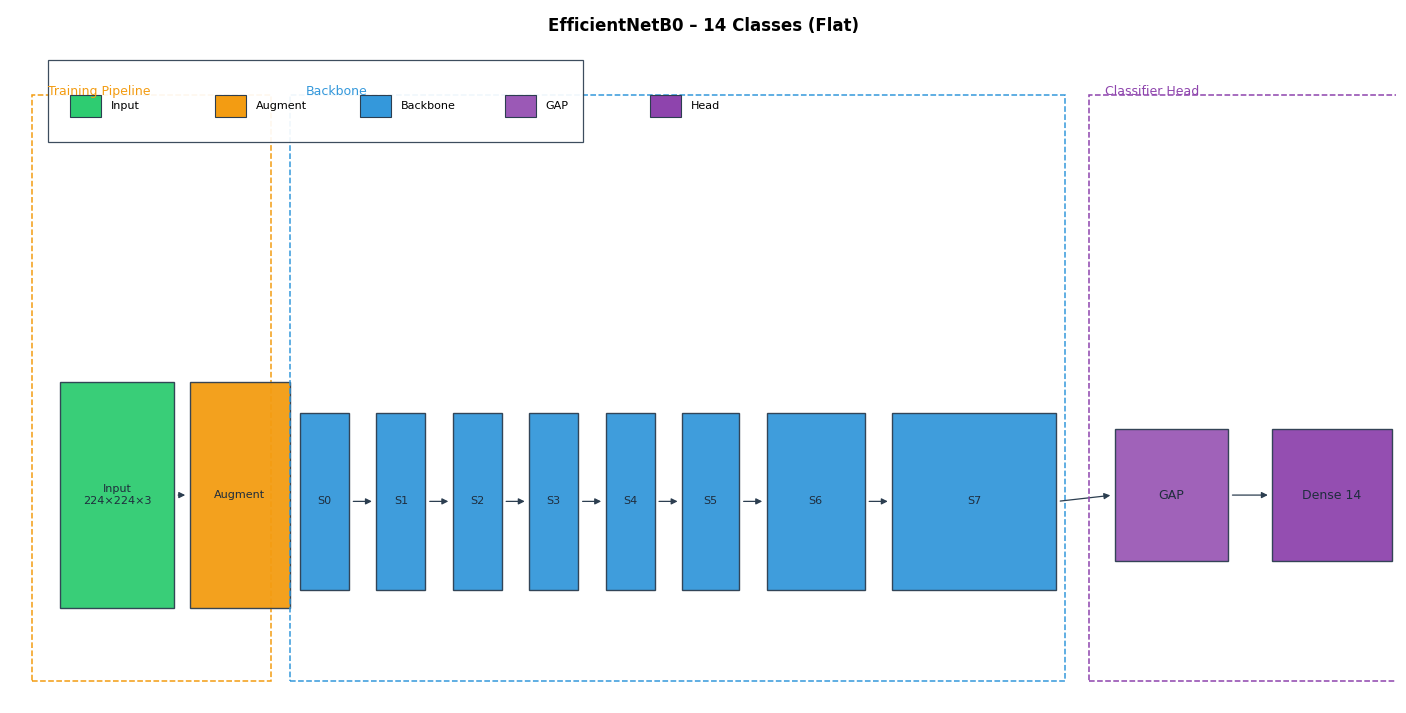

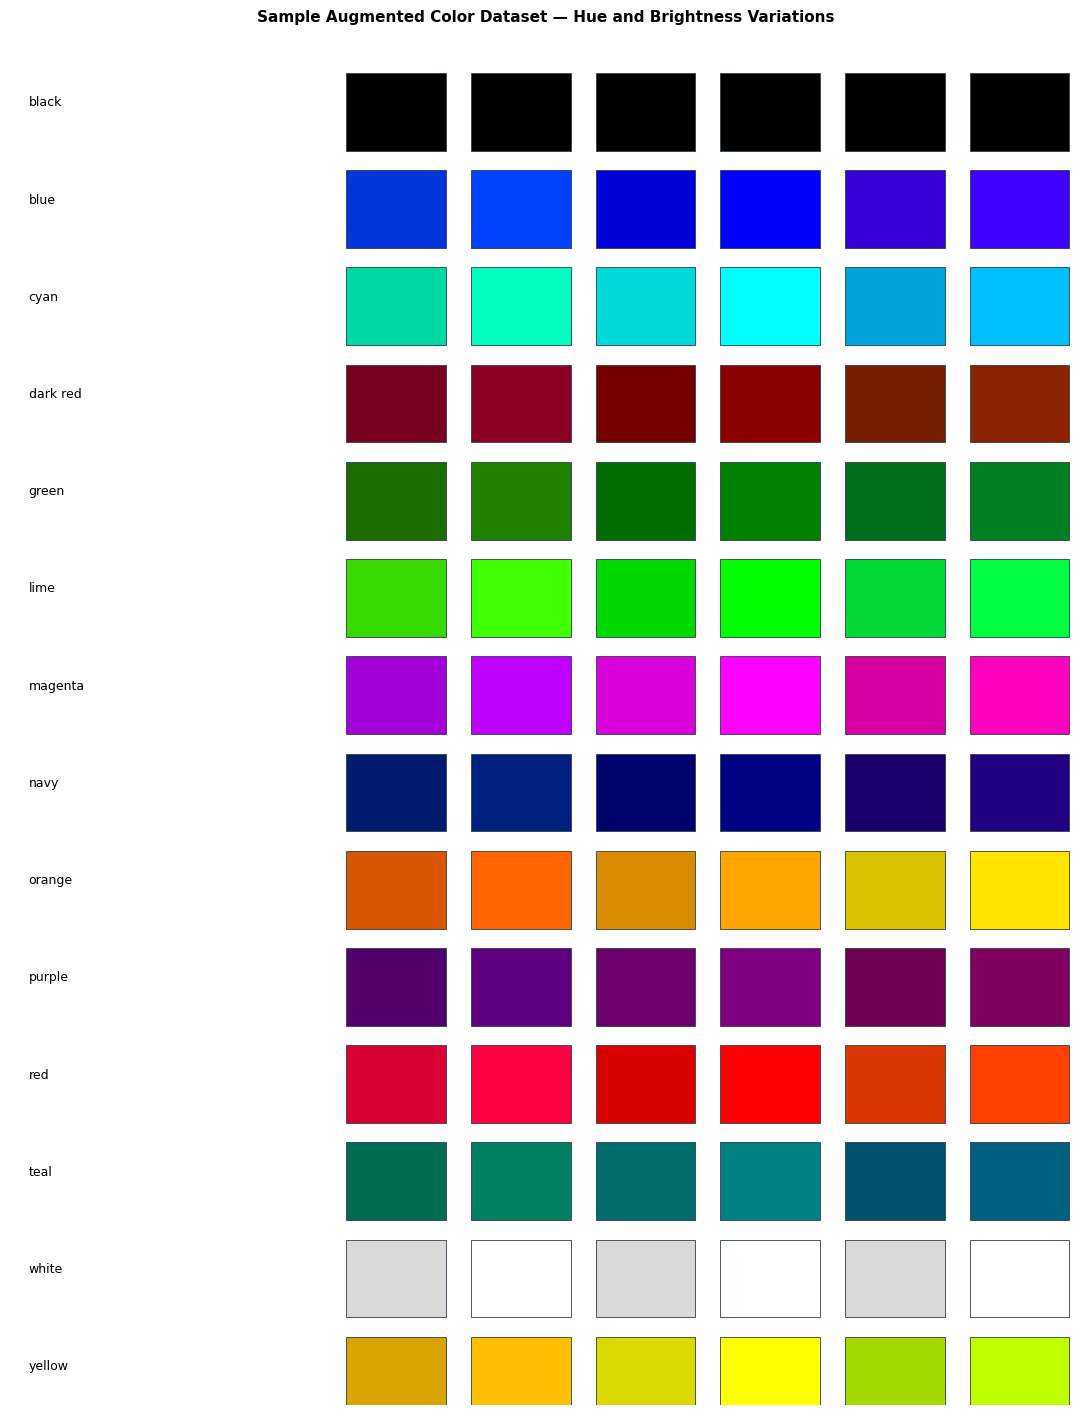

In [32]:
# Simple 14-class EfficientNetB0 diagram (flat 2D blocks)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from pathlib import Path

FIG_PATH = REPORTS_DIR / 'architecture_14class_flat.png'
FIG_SVG = REPORTS_DIR / 'architecture_14class_flat.svg'
LETTER_PATH = REPORTS_DIR / 'architecture_14class_flat_letter.png'

plt.close('all')

# Compact canvas with equal aspect (no distortion)
X_MIN, X_MAX = 0, 44
Y_MIN, Y_MAX = 0, 22
X_SPAN = X_MAX - X_MIN
Y_SPAN = Y_MAX - Y_MIN
HEIGHT_IN = 7.0
WIDTH_IN = HEIGHT_IN * (X_SPAN / Y_SPAN)

fig, ax = plt.subplots(figsize=(WIDTH_IN, HEIGHT_IN))
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_aspect('equal', adjustable='box')
ax.axis('off')

# Helpers

def draw_block(x, y, w, h, face_color, label, edge=EDGE_COLOR, fontsize=8, radius=0.0):
    front = Rectangle((x, y), w, h, facecolor=face_color, edgecolor=edge, linewidth=1.0, alpha=0.95)
    ax.add_patch(front)
    ax.text(x + w/2, y + h/2, label, fontsize=fontsize, ha='center', va='center', color=TEXT_COLOR)
    return {'x': x, 'y': y, 'w': w, 'h': h}


def arrow(a, b):
    ax.add_patch(FancyArrowPatch((a['x'] + a['w'] + 0.05, a['y'] + a['h']/2),
                                 (b['x'] - 0.05, b['y'] + b['h']/2),
                                 arrowstyle='-|>', mutation_scale=9, linewidth=0.9, color=EDGE_COLOR))

# Groups (dashed frames)
from matplotlib.patches import Rectangle as _Rect

def group_box(x, y, w, h, title, color):
    ax.add_patch(_Rect((x-0.3, y-0.3), w+0.6, h+0.6, fill=False, edgecolor=color, linestyle='--', linewidth=1.1))
    ax.text(x + 0.2, y + h + 0.2, title, fontsize=9, ha='left', va='bottom', color=color)

# Layout
base_y = 3
train_x = 1
train_w = 7.0
group_box(train_x, 1, train_w, 18, 'Training Pipeline', COL_AUG)

inp = draw_block(train_x + 0.6, base_y, 3.6, 7.2, COL_INPUT, 'Input\n224×224×3', fontsize=8)
aug = draw_block(train_x + 4.7, base_y, 3.2, 7.2, COL_AUG, 'Augment', fontsize=8)
narrow_arrow1 = arrow(inp, aug)

# Backbone (S0..S7 only)
backbone_x = 9.2
stages = [('S0', 32), ('S1', 16), ('S2', 24), ('S3', 40), ('S4', 80), ('S5', 112), ('S6', 192), ('S7', 320)]
max_out = max(c for _, c in stages)
base_units = 6.0 / max_out
min_w = 1.8
gap = 1.0

# auto-fit if too wide
raw_widths = [max(min_w, c*base_units) for _, c in stages]
reserve = 1.0 + 3.6 + 1.2 + 3.8 + 1.2
span = sum(raw_widths) + gap*(len(stages)-1)
avail = X_MAX - backbone_x - reserve
shrink = min(1.0, avail/span)
widths = [w*shrink for w in raw_widths]
gap_s = gap*shrink

x = backbone_x
backbone_blocks = []
for (sid, _), w in zip(stages, widths):
    blk = draw_block(x, base_y + 0.6, w, 5.6, COL_FEAT, sid, fontsize=8)
    backbone_blocks.append(blk)
    x += w + gap_s

backbone_w = x - backbone_x - gap_s
group_box(backbone_x, 1, backbone_w, 18, 'Backbone', COL_FEAT)
for a, b in zip(backbone_blocks[:-1], backbone_blocks[1:]):
    arrow(a, b)

# Head (GAP -> Dense 14), flat 2D blocks
gap_x = x + 1.0
pool = draw_block(gap_x, base_y + 1.5, 3.6, 4.2, COL_GAP, 'GAP', fontsize=9)
head = draw_block(gap_x + 5.0, base_y + 1.5, 3.8, 4.2, COL_HEAD, 'Dense 14', fontsize=9)
narrow_arrow2 = arrow(backbone_blocks[-1], pool)
narrow_arrow3 = arrow(pool, head)

head_group_w = (head['x'] + head['w']) - (pool['x'] - 0.5)
group_box(pool['x'] - 0.5, 1, head_group_w, 18, 'Classifier Head', COL_HEAD)

# Minimal legend
legend_items = [
    (COL_INPUT, 'Input'),
    (COL_AUG, 'Augment'),
    (COL_FEAT, 'Backbone'),
    (COL_GAP, 'GAP'),
    (COL_HEAD, 'Head')
]
leg_x, leg_y = X_MIN + 1.2, Y_MAX - 4.2
ax.add_patch(_Rect((leg_x, leg_y), 17, 2.6, facecolor='white', edgecolor=EDGE_COLOR, linewidth=0.9, alpha=0.92))
px = leg_x + 0.7
for col, txt in legend_items:
    ax.add_patch(_Rect((px, leg_y + 0.8), 1.0, 0.7, facecolor=col, edgecolor=EDGE_COLOR, linewidth=0.8))
    ax.text(px + 1.3, leg_y + 1.15, txt, fontsize=8, va='center', ha='left')
    px += 4.6

# Title
ax.text(X_MIN + X_SPAN/2, Y_MAX - 0.8, 'EfficientNetB0 – 14 Classes (Flat)', fontsize=12, ha='center', va='bottom', weight='bold')

fig.tight_layout(pad=0.25)
fig.savefig(FIG_PATH, dpi=230, bbox_inches='tight')
fig.savefig(FIG_SVG, bbox_inches='tight')

# Letter export
figL, axL = plt.subplots(figsize=(11, 8.5))
axL.set_xlim(X_MIN, X_MAX); axL.set_ylim(Y_MIN, Y_MAX); axL.set_aspect('equal', adjustable='box'); axL.axis('off')
img = plt.imread(FIG_PATH); axL.imshow(img, extent=(X_MIN, X_MAX, Y_MIN, Y_MAX))
figL.tight_layout(pad=0.2); figL.savefig(LETTER_PATH, dpi=230, bbox_inches='tight'); plt.close(figL)

print(f'Flat diagram saved: {FIG_PATH}\nSVG: {FIG_SVG}\nLetter: {LETTER_PATH}')

# ------------------------------------------------------------------
# Dataset Sample Grid (Hue and Brightness Variations) for 14 classes
# ------------------------------------------------------------------
import colorsys

SAMPLES_PATH = REPORTS_DIR / 'dataset_samples.png'
SAMPLES_LETTER = REPORTS_DIR / 'dataset_samples_letter.png'

CLASS_NAMES = ['black','blue','cyan','dark_red','green','lime','magenta','navy','orange','purple','red','teal','white','yellow']
BASE_RGB_255 = {
    'black': (0, 0, 0),
    'blue': (0, 0, 255),
    'cyan': (0, 255, 255),
    'dark_red': (139, 0, 0),
    'green': (0, 128, 0),
    'lime': (0, 255, 0),
    'magenta': (255, 0, 255),
    'navy': (0, 0, 128),
    'orange': (255, 165, 0),
    'purple': (128, 0, 128),
    'red': (255, 0, 0),
    'teal': (0, 128, 128),
    'white': (255, 255, 255),
    'yellow': (255, 255, 0),
}

# Variants: (hue shift degrees, brightness factor)
VARIANTS = [(-15, 0.85), (-15, 1.0), (0, 0.85), (0, 1.0), (15, 0.85), (15, 1.0)]

# Utility to apply hue and value shifts in HSV space

def adjust_hv(rgb255, dh_deg, v_scale):
    r, g, b = [c/255.0 for c in rgb255]
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    h = (h + dh_deg/360.0) % 1.0
    v = max(0.0, min(1.0, v * v_scale))
    rr, gg, bb = colorsys.hsv_to_rgb(h, s, v)
    return (rr, gg, bb)

rows = len(CLASS_NAMES)
cols = len(VARIANTS)

# Figure sizing: wide grid with left margin for row labels
left_label_w = 2.6
cell_w = 1.2
cell_h = 0.9
width_in = left_label_w + cols * cell_w + 1.0
height_in = rows * cell_h + 1.4

fig2, ax2 = plt.subplots(figsize=(width_in, height_in))
ax2.set_xlim(0, left_label_w + cols)
ax2.set_ylim(0, rows)
ax2.axis('off')

# Column headers (variant description)
for j, (dh, vf) in enumerate(VARIANTS):
    ax2.text(left_label_w + j + 0.5, rows - 0.5, f'H {dh:+}° / V×{vf:.2f}', ha='center', va='center', fontsize=8)

# Draw grid of colored rectangles
for i, name in enumerate(CLASS_NAMES):
    y = rows - (i + 1) - 0.1
    # Row label
    ax2.text(0.15, y + 0.5, name.replace('_',' '), ha='left', va='center', fontsize=9)
    base = BASE_RGB_255[name]
    for j, (dh, vf) in enumerate(VARIANTS):
        x = left_label_w + j + 0.1
        col = adjust_hv(base, dh, vf)
        ax2.add_patch(Rectangle((x, y), 0.8, 0.8, facecolor=col, edgecolor=EDGE_COLOR, linewidth=0.6))

ax2.text((left_label_w + cols)/2, rows + 0.2, 'Sample Augmented Color Dataset — Hue and Brightness Variations',
         ha='center', va='bottom', fontsize=11, weight='bold')

fig2.tight_layout(pad=0.3)
fig2.savefig(SAMPLES_PATH, dpi=220, bbox_inches='tight')

# Letter layout wrapper for easy print
fig2L, ax2L = plt.subplots(figsize=(11, 8.5))
ax2L.axis('off')
img2 = plt.imread(SAMPLES_PATH)
ax2L.imshow(img2)
fig2L.tight_layout(pad=0.2)
fig2L.savefig(SAMPLES_LETTER, dpi=230, bbox_inches='tight')
plt.close(fig2L)

print(f'Dataset samples saved: {SAMPLES_PATH} and {SAMPLES_LETTER}')

In [5]:
# Pure TensorFlow per-image augmentation with targeted navy/blue/purple enhancements
import tensorflow as tf

if 'ds_train' in globals():
    AUTOTUNE = tf.data.AUTOTUNE
    NAVY_IDX = LABELS.index('navy') if 'navy' in LABELS else -1
    BLUE_IDX = LABELS.index('blue') if 'blue' in LABELS else -1
    PURPLE_IDX = LABELS.index('purple') if 'purple' in LABELS else -1

    def _to01(x):
        return tf.clip_by_value(x / 255.0, 0.0, 1.0)

    def _to255(x):
        return tf.clip_by_value(x * 255.0, 0.0, 255.0)

    def _augment_image(img, label):
        img = tf.cast(img, tf.float32)
        # Generic light jitter
        delta = tf.random.uniform([], -0.08, 0.08)
        img = tf.image.adjust_brightness(img, delta)
        contrast = tf.random.uniform([], 0.92, 1.08)
        img = tf.image.adjust_contrast(img, contrast)
        # Optional light blur (25%)
        def _blur():
            return tf.nn.avg_pool2d(tf.expand_dims(img, 0), ksize=3, strides=1, padding='SAME')[0]
        img = tf.cond(tf.random.uniform([], 0, 1) < 0.25, _blur, lambda: img)

        cls_idx = tf.argmax(label, axis=-1)

        # Navy: darker via gamma>1, more saturated, slight negative hue shift
        def navy_aug(x):
            x01 = _to01(x)
            gamma = tf.random.uniform([], 1.2, 1.6)  # >1 darkens
            x01 = tf.pow(tf.clip_by_value(x01, 0.0, 1.0), gamma)
            x01 = tf.image.adjust_saturation(x01, tf.random.uniform([], 1.10, 1.30))
            x01 = tf.image.adjust_hue(x01, tf.random.uniform([], -0.02, -0.005))
            return _to255(x01)

        # Blue: brighter via gamma<1, slightly desaturated
        def blue_aug(x):
            x01 = _to01(x)
            gamma = tf.random.uniform([], 0.70, 0.90)  # <1 brightens
            # For brighten, invert gamma relation: x^(gamma)
            x01 = tf.pow(tf.clip_by_value(x01, 0.0, 1.0), gamma)
            x01 = tf.image.adjust_saturation(x01, tf.random.uniform([], 0.80, 0.95))
            return _to255(x01)

        # Purple: increase saturation + tiny hue jitter (unchanged)
        def purple_aug(x):
            x01 = _to01(x)
            x01 = tf.image.adjust_saturation(x01, tf.random.uniform([], 1.05, 1.25))
            x01 = tf.image.adjust_hue(x01, tf.random.uniform([], -0.015, 0.015))
            return _to255(tf.clip_by_value(x01, 0.0, 1.0))

        if NAVY_IDX >= 0:
            img = tf.cond(tf.equal(cls_idx, NAVY_IDX), lambda: navy_aug(img), lambda: img)
        if BLUE_IDX >= 0:
            img = tf.cond(tf.equal(cls_idx, BLUE_IDX), lambda: blue_aug(img), lambda: img)
        if PURPLE_IDX >= 0:
            img = tf.cond(tf.equal(cls_idx, PURPLE_IDX), lambda: purple_aug(img), lambda: img)

        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    ds_train = (ds_train
                .unbatch()
                .map(_augment_image, num_parallel_calls=AUTOTUNE)
                .batch(BATCH)
                .prefetch(AUTOTUNE))
    print('Applied per-image TF augmentation with targeted navy/blue/purple adjustments.')
else:
    print('ds_train not defined yet; run dataset build cell first.')


Applied per-image TF augmentation with targeted navy/blue/purple adjustments.


In [33]:
# Pure TensorFlow per-image augmentation (stability-first, unbatch/rebatch)
import tensorflow as tf

if 'ds_train' in globals():
    AUTOTUNE = tf.data.AUTOTUNE

    def _augment_image(img, label):
        img = tf.cast(img, tf.float32)
        # Brightness shift
        delta = tf.random.uniform([], -0.12, 0.12)
        img = tf.image.adjust_brightness(img, delta)
        # Contrast adjust
        contrast = tf.random.uniform([], 0.9, 1.1)
        img = tf.image.adjust_contrast(img, contrast)
        # Optional light blur via average pooling (25% chance)
        def _blur():
            return tf.nn.avg_pool2d(tf.expand_dims(img, 0), ksize=3, strides=1, padding='SAME')[0]
        img = tf.cond(tf.random.uniform([], 0, 1) < 0.25, _blur, lambda: img)
        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    # Unbatch -> per-image augment -> rebatch
    ds_train = (ds_train
                .unbatch()
                .map(_augment_image, num_parallel_calls=AUTOTUNE)
                .batch(BATCH)
                .prefetch(AUTOTUNE))
    print('Applied per-image pure TF augmentation (brightness, contrast, optional blur).')
else:
    print('ds_train not defined yet; run dataset build cell first.')

Applied per-image pure TF augmentation (brightness, contrast, optional blur).


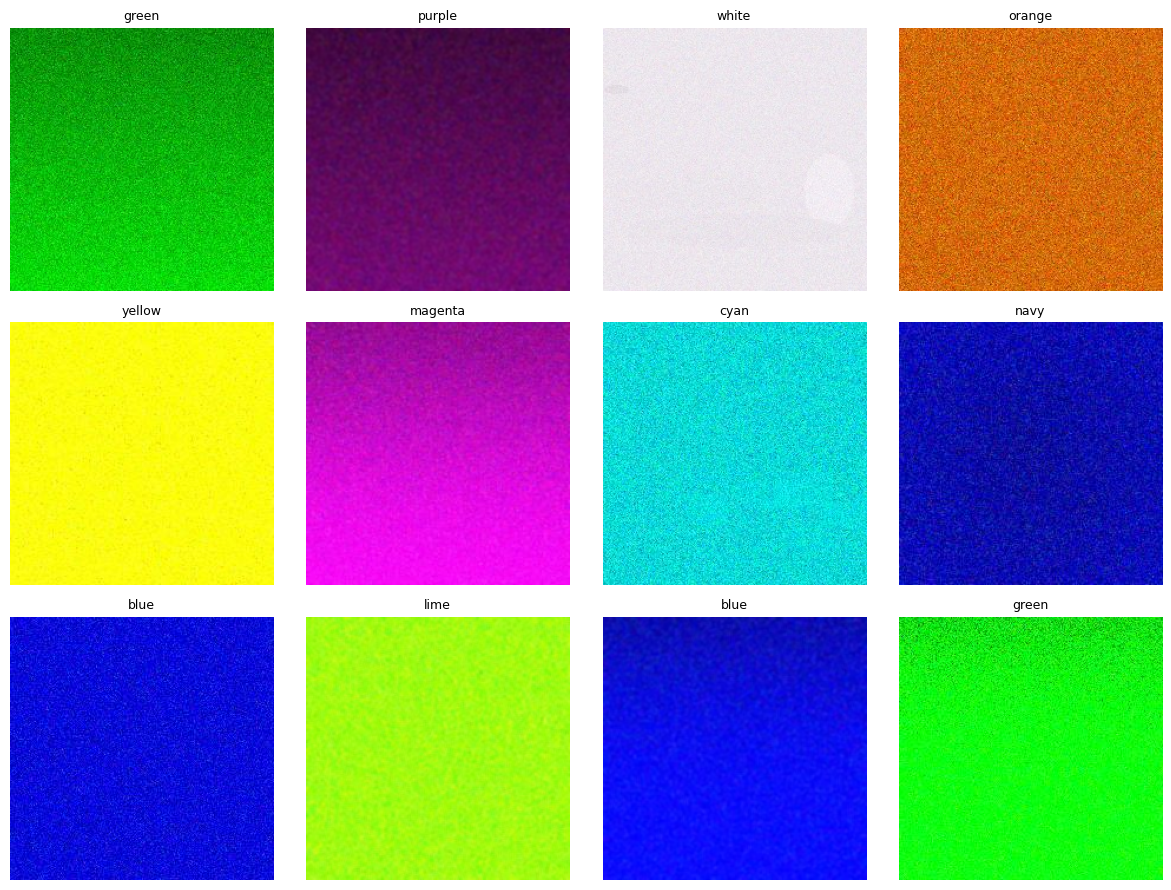

Shown 12 augmented samples (pure TF).


In [28]:
# Visualize a grid of augmented samples from ds_train (pure TF aug)
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from math import ceil

images, labels = next(iter(ds_train))
imgs_np = images.numpy()
lbls_np = labels.numpy()
N = min(12, imgs_np.shape[0])
cols = 4
rows = ceil(N/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = np.array(axes).reshape(-1)
for i in range(rows*cols):
    ax = axes[i]
    ax.axis('off')
    if i < N:
        img = np.clip(imgs_np[i], 0, 255).astype(np.uint8)
        cls_idx = int(np.argmax(lbls_np[i]))
        ax.imshow(img)
        ax.set_title(f'{LABELS[cls_idx]}', fontsize=9)
plt.tight_layout()
plt.show()
print(f'Shown {N} augmented samples (pure TF).')

In [29]:
# Stratified 19-class split preparation (awaiting data population)
import os, shutil, json, random, hashlib
from pathlib import Path
import math

# Configuration for Phase 3 split
SOURCE_DIR = DATA_ROOT / 'v5_all'          # User will populate: 19 folders ~400 imgs each
SPLIT_ROOT = DATA_ROOT / 'v5_split'        # Output root we will create
TRAIN_DIR = SPLIT_ROOT / 'train'
VAL_DIR   = SPLIT_ROOT / 'val'
CLASS_LIST_19 = [
    'beige_tan','black','blue','brown','cyan','gold','gray','green','lime','magenta',
    'navy','orange','pink','purple','red','silver','teal','white','yellow'
]
VAL_COUNT_PER_CLASS = 60   # target validation count
SEED_SPLIT = 42
IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}
MANIFEST_JSON = SPLIT_ROOT / 'split_manifest.json'

print('--- Split Script (Preparation Phase) ---')
print('Source directory:', SOURCE_DIR)
print('Target split root:', SPLIT_ROOT)

# Utility: deterministic shuffle using seed
_rng = random.Random(SEED_SPLIT)

def _gather_images(class_name):
    cls_dir = SOURCE_DIR / class_name
    if not cls_dir.is_dir():
        return []
    files = []
    for fn in os.listdir(cls_dir):
        ext = os.path.splitext(fn)[1].lower()
        if ext in IMAGE_EXTS:
            files.append(cls_dir / fn)
    return files

# Dry-run inspection (do not create if source not ready)
missing = [c for c in CLASS_LIST_19 if not (SOURCE_DIR / c).is_dir()]
if missing:
    print('NOTE: Missing class folders (waiting for user population):')
    for m in missing:
        print('  -', m)
    print('No split performed yet. Populate SOURCE_DIR then re-run this cell.')
else:
    # Check if already split with expected structure
    already_ok = True
    if TRAIN_DIR.is_dir() and VAL_DIR.is_dir():
        for c in CLASS_LIST_19:
            if not (TRAIN_DIR / c).is_dir() or not (VAL_DIR / c).is_dir():
                already_ok = False
                break
    else:
        already_ok = False

    if already_ok:
        print('Existing split found; skipping recreation. (Delete v5_split to regenerate)')
    else:
        print('Creating stratified split...')
        # (Re)create directories
        if SPLIT_ROOT.exists():
            print('Removing existing split root for clean rebuild.')
            shutil.rmtree(SPLIT_ROOT)
        TRAIN_DIR.mkdir(parents=True, exist_ok=True)
        VAL_DIR.mkdir(parents=True, exist_ok=True)
        for c in CLASS_LIST_19:
            (TRAIN_DIR / c).mkdir(parents=True, exist_ok=True)
            (VAL_DIR / c).mkdir(parents=True, exist_ok=True)

        manifest = {
            'seed': SEED_SPLIT,
            'val_count_target': VAL_COUNT_PER_CLASS,
            'classes': CLASS_LIST_19,
            'entries': []
        }

        for c in CLASS_LIST_19:
            files = _gather_images(c)
            _rng.shuffle(files)
            total = len(files)
            if total == 0:
                print(f'WARNING: Class {c} has 0 images; skipping.')
                manifest['entries'].append({'class': c, 'total': 0, 'train': 0, 'val': 0})
                continue
            val_n = min(VAL_COUNT_PER_CLASS, max(1, total // 6)) if total < VAL_COUNT_PER_CLASS else VAL_COUNT_PER_CLASS
            train_n = total - val_n
            val_files = files[:val_n]
            train_files = files[val_n:]
            # Copy
            for src in train_files:
                dst = TRAIN_DIR / c / src.name
                shutil.copy2(src, dst)
            for src in val_files:
                dst = VAL_DIR / c / src.name
                shutil.copy2(src, dst)
            manifest['entries'].append({'class': c, 'total': total, 'train': train_n, 'val': val_n})
            print(f'Class {c}: total={total} train={train_n} val={val_n}')

        with open(MANIFEST_JSON, 'w', encoding='utf-8') as f:
            json.dump(manifest, f, indent=2)
        print('Split manifest written ->', MANIFEST_JSON)

        # Basic integrity checks
        ok = True
        for rec in manifest['entries']:
            c = rec['class']
            train_ct = len(list((TRAIN_DIR / c).glob('*')))
            val_ct = len(list((VAL_DIR / c).glob('*')))
            if train_ct != rec['train'] or val_ct != rec['val']:
                ok = False
                print(f'Count mismatch for {c}: manifest train={rec["train"]} actual={train_ct}; val={rec["val"]} actual={val_ct}')
        print('Integrity check:', 'PASS' if ok else 'FAIL')

print('--- End Split Script Cell ---')


--- Split Script (Preparation Phase) ---
Source directory: c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\data\v5_all
Target split root: c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\data\v5_split
Creating stratified split...
Class beige_tan: total=400 train=340 val=60
Class beige_tan: total=400 train=340 val=60
Class black: total=300 train=240 val=60
Class black: total=300 train=240 val=60
Class blue: total=400 train=340 val=60
Class blue: total=400 train=340 val=60
Class brown: total=400 train=340 val=60
Class brown: total=400 train=340 val=60
Class cyan: total=400 train=340 val=60
Class cyan: total=400 train=340 val=60
Class gold: total=400 train=340 val=60
Class gold: total=400 train=340 val=60
Class gray: total=400 train=340 val=60
Class gray: total=400 train=340 val=60
Class green: total=400 train=340 val=60
Class green: total=400 train=340 val=60
Class lime: total=400 train=340 val=60
Class lime: total=400 train=340 val=60
Class m

In [5]:
# Quick setup for report paths if kernel restarted
import os
from pathlib import Path
EXPORT_DIR = "../../export"
os.makedirs(EXPORT_DIR, exist_ok=True)
MODEL_FOR_EXPORT = str(Path.cwd() / 'Color-Classification-CNN' / 'models' / 'final' / 'color_model_effb0_19cls_aug_improved.keras')
print('EXPORT_DIR =', EXPORT_DIR)
print('MODEL_FOR_EXPORT =', MODEL_FOR_EXPORT, '| exists =', os.path.exists(MODEL_FOR_EXPORT))


EXPORT_DIR = ../../export
MODEL_FOR_EXPORT = c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras | exists = True


In [8]:
# Inspect export directory for generated artifacts
import os
print('Export contents:')
for fn in sorted(os.listdir(EXPORT_DIR)):
    print(' -', fn)


Export contents:
 - confusion_matrix_19.csv
 - confusion_matrix_19_norm.csv
 - temperature_19.json


In [9]:
# Generate 19-class classification report CSV (ad hoc)
import os, csv as _csv, numpy as _np, tensorflow as tf
from tensorflow import keras

CR_CSV = os.path.join(EXPORT_DIR, 'classification_report_19.csv')

val_ds_cat = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

rep_model = keras.models.load_model(MODEL_FOR_EXPORT, compile=False)

Y_true = []
Y_pred = []
for xb, yb in val_ds_cat:
    p = rep_model(xb, training=False).numpy()
    Y_true.append(yb.numpy())
    Y_pred.append(p)

y_true = _np.concatenate(Y_true, axis=0)
y_pred = _np.concatenate(Y_pred, axis=0)

y_true_idx = _np.argmax(y_true, axis=1)
y_pred_idx = _np.argmax(y_pred, axis=1)

rows = []
for i, name in enumerate(LABELS):
    tp = _np.sum((y_true_idx==i) & (y_pred_idx==i))
    fp = _np.sum((y_true_idx!=i) & (y_pred_idx==i))
    fn = _np.sum((y_true_idx==i) & (y_pred_idx!=i))
    support = _np.sum(y_true_idx==i)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    rows.append((name, prec, rec, f1, float(support)))

precs = [r[1] for r in rows]
recs  = [r[2] for r in rows]
f1s   = [r[3] for r in rows]
supps = [r[4] for r in rows]

total = sum(supps) if sum(supps)>0 else 1.0
macro = (float(_np.mean(precs)), float(_np.mean(recs)), float(_np.mean(f1s)), float(total))
weights = _np.array(supps)/total
weighted = (float(_np.sum(weights*precs)), float(_np.sum(weights*recs)), float(_np.sum(weights*f1s)), float(total))

with open(CR_CSV, 'w', newline='', encoding='utf-8') as f:
    w = _csv.writer(f)
    w.writerow(['class','precision','recall','f1','support'])
    for name, prec, rec, f1, sup in rows:
        w.writerow([name, prec, rec, f1, sup])
    w.writerow(['macro avg', macro[0], macro[1], macro[2], macro[3]])
    w.writerow(['weighted avg', weighted[0], weighted[1], weighted[2], weighted[3]])

print('Classification report written to', CR_CSV)
print('Macro F1:', macro[2], 'Weighted F1:', weighted[2])


Found 1140 files belonging to 19 classes.
Classification report written to ../../export\classification_report_19.csv
Macro F1: 0.8247094330468948 Weighted F1: 0.8247094330468947


In [10]:
# Confusion pair analysis (in-memory, independent of saved CSV paths)
import tensorflow as tf, numpy as np, os
from tensorflow import keras
from collections import defaultdict

ANALYSIS_MODEL = keras.models.load_model(MODEL_FOR_EXPORT, compile=False)
val_ds_int = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='int',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y))

true_labels = []
pred_labels = []
for xb, yb in val_ds_int:
    probs = ANALYSIS_MODEL(xb, training=False).numpy()
    pred = np.argmax(probs, axis=1)
    true_labels.extend(yb.numpy().tolist())
    pred_labels.extend(pred.tolist())

true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)
num_classes = len(LABELS)
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(true_labels, pred_labels):
    cm[t, p] += 1

# Pairs to inspect
pairs = [
    ('silver','gray'),
    ('gold','yellow'),
    ('blue','navy'),
    ('beige_tan','brown'),
    ('pink','purple'),
]

index = {name: i for i, name in enumerate(LABELS)}
report_rows = []
for a, b in pairs:
    ia, ib = index[a], index[b]
    total_a = cm[ia].sum()
    total_b = cm[ib].sum()
    a_to_b = cm[ia, ib]
    b_to_a = cm[ib, ia]
    a_self = cm[ia, ia]
    b_self = cm[ib, ib]
    report_rows.append({
        'pair': f'{a} ↔ {b}',
        f'{a}_correct': int(a_self),
        f'{b}_correct': int(b_self),
        f'{a}_to_{b}': int(a_to_b),
        f'{b}_to_{a}': int(b_to_a),
        f'{a}_to_{b}_pct': a_to_b / total_a if total_a else 0.0,
        f'{b}_to_{a}_pct': b_to_a / total_b if total_b else 0.0,
    })

print('Key Confusion Pairs (counts and row-wise pct):')
for r in report_rows:
    print('\nPair:', r['pair'])
    print('  ', list(r.keys())[1:])
    print(f"  {r['pair']}: {r[f'{r['pair'].split(' ↔ ')[0]}_correct']} correct vs {r[f'{r['pair'].split(' ↔ ')[1]}_correct']} correct")
    for k,v in r.items():
        if k.endswith('_pct'):
            print(f'   {k}: {v*100:.2f}%')
    print(f"   {r['pair'].split(' ↔ ')[0]} -> {r['pair'].split(' ↔ ')[1]}: {r[f'{r['pair'].split(' ↔ ')[0]}_to_{r['pair'].split(' ↔ ')[1]}']} | {r[f'{r['pair'].split(' ↔ ')[1]}_to_{r['pair'].split(' ↔ ')[0]}']} the other way")

# Compact summary table
print('\nSummary Table:')
print('pair,a_correct,b_correct,a->b,b->a,a->b_pct,b->a_pct')
for r in report_rows:
    a, b = r['pair'].split(' ↔ ')
    print(f"{r['pair']},{r[f'{a}_correct']},{r[f'{b}_correct']},{r[f'{a}_to_{b}']},{r[f'{b}_to_{a}']},{r[f'{a}_to_{b}_pct']:.4f},{r[f'{b}_to_{a}_pct']:.4f}")


Found 1140 files belonging to 19 classes.
Key Confusion Pairs (counts and row-wise pct):

Pair: silver ↔ gray
   ['silver_correct', 'gray_correct', 'silver_to_gray', 'gray_to_silver', 'silver_to_gray_pct', 'gray_to_silver_pct']
  silver ↔ gray: 60 correct vs 60 correct
   silver_to_gray_pct: 0.00%
   gray_to_silver_pct: 0.00%
   silver -> gray: 0 | 0 the other way

Pair: gold ↔ yellow
   ['gold_correct', 'yellow_correct', 'gold_to_yellow', 'yellow_to_gold', 'gold_to_yellow_pct', 'yellow_to_gold_pct']
  gold ↔ yellow: 59 correct vs 60 correct
   gold_to_yellow_pct: 0.00%
   yellow_to_gold_pct: 0.00%
   gold -> yellow: 0 | 0 the other way

Pair: blue ↔ navy
   ['blue_correct', 'navy_correct', 'blue_to_navy', 'navy_to_blue', 'blue_to_navy_pct', 'navy_to_blue_pct']
  blue ↔ navy: 53 correct vs 14 correct
   blue_to_navy_pct: 0.00%
   navy_to_blue_pct: 70.00%
   blue -> navy: 0 | 42 the other way

Pair: beige_tan ↔ brown
   ['beige_tan_correct', 'brown_correct', 'beige_tan_to_brown', 'brown

In [21]:
# Force smoke training run (1 epoch) ensuring model and ds_train exist
import tensorflow as tf, numpy as np
from tensorflow import keras

if 'EPOCHS' in globals():
    EPOCHS = 1
else:
    EPOCHS = 1

# Build model if missing
if 'model' not in globals() or not isinstance(model, keras.Model):
    def build_model(backbone=BACKBONE, dropout=DROPOUT, use_imagenet=USE_IMAGENET):
        inp = keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
        x = data_augmentation(inp)
        x = tf.keras.applications.efficientnet.preprocess_input(x)
        weights = 'imagenet' if use_imagenet else None
        try:
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        except Exception:
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        x = base(x)
        if dropout and dropout > 0:
            x = keras.layers.Dropout(dropout)(x)
        out = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
        return keras.Model(inp, out)
    model = build_model()
    optimizer = keras.optimizers.Adam(learning_rate=LR)
    loss = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
    metrics = [keras.metrics.CategoricalAccuracy(name='acc')]
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Ensure ds_train augmented pipeline exists
if 'ds_train' not in globals():
    raise RuntimeError('ds_train not defined; run dataset build cells first.')

print('Starting forced 1-epoch smoke train...')
h = model.fit(ds_train, validation_data=ds_val, epochs=1, verbose=1)
print('Done. val_acc=', h.history.get('val_acc', ['?'])[-1] if h.history.get('val_acc') else 'n/a')


Starting forced 1-epoch smoke train...
196/196 ━━━━━━━━━━━━━━━━━━━━ 1316s 7s/step - acc: 0.9596 - loss: 0.7331 - val_acc: 0.8886 - val_loss: 0.8563
196/196 ━━━━━━━━━━━━━━━━━━━━ 1316s 7s/step - acc: 0.9596 - loss: 0.7331 - val_acc: 0.8886 - val_loss: 0.8563
Done. val_acc= 0.8885964751243591
Done. val_acc= 0.8885964751243591


In [22]:
# Re-run confusion pair analysis after targeted augmentation smoke run
import numpy as np, tensorflow as tf
from collections import defaultdict

print('Collecting validation predictions for updated confusion analysis...')
val_images = []
val_labels = []
for batch in ds_val:
    imgs, labs = batch
    val_images.append(imgs)
    val_labels.append(labs)
val_images = tf.concat(val_images, axis=0)
val_labels = tf.concat(val_labels, axis=0)
probs = model.predict(val_images, verbose=0)
preds = tf.argmax(probs, axis=1).numpy()
true = tf.argmax(val_labels, axis=1).numpy()

idx_to_class = CLASS_NAMES
class_to_idx = {c:i for i,c in enumerate(idx_to_class)}

def count_confusions(a,b):
    ai = class_to_idx[a]; bi = class_to_idx[b]
    a_to_b = int(np.sum((true==ai) & (preds==bi)))
    b_to_a = int(np.sum((true==bi) & (preds==ai)))
    a_total = int(np.sum(true==ai))
    b_total = int(np.sum(true==bi))
    return {
        'pair': f'{a}<->{b}',
        f'{a}->${b}': a_to_b,
        f'{b}->${a}': b_to_a,
        f'{a}_total': a_total,
        f'{b}_total': b_total,
        f'{a}_pct_to_{b}': round(100.0 * a_to_b / max(1,a_total),2),
        f'{b}_pct_to_{a}': round(100.0 * b_to_a / max(1,b_total),2)
    }

pairs = [
    ('silver','gray'),
    ('gold','yellow'),
    ('blue','navy'),
    ('beige_tan','brown'),
    ('pink','purple'),
]

results = []
for a,b in pairs:
    results.append(count_confusions(a,b))

print('Updated targeted confusion pairs:')
for r in results:
    print(r)

# Specific focus on navy->blue reduction
navy_blue = [r for r in results if r['pair']=='blue<->navy'][0]
print('\nFocus: navy->blue % now:', navy_blue['blue_pct_to_navy'] if 'blue_pct_to_navy' in navy_blue else 'N/A')
print('Focus: blue->navy % now:', navy_blue['navy_pct_to_blue'] if 'navy_pct_to_blue' in navy_blue else 'N/A')


Updated targeted confusion pairs:
{'pair': 'silver<->gray', 'silver->$gray': 0, 'gray->$silver': 0, 'silver_total': 60, 'gray_total': 60, 'silver_pct_to_gray': 0.0, 'gray_pct_to_silver': 0.0}
{'pair': 'gold<->yellow', 'gold->$yellow': 0, 'yellow->$gold': 0, 'gold_total': 60, 'yellow_total': 60, 'gold_pct_to_yellow': 0.0, 'yellow_pct_to_gold': 0.0}
{'pair': 'blue<->navy', 'blue->$navy': 0, 'navy->$blue': 43, 'blue_total': 60, 'navy_total': 60, 'blue_pct_to_navy': 0.0, 'navy_pct_to_blue': 71.67}
{'pair': 'beige_tan<->brown', 'beige_tan->$brown': 0, 'brown->$beige_tan': 0, 'beige_tan_total': 60, 'brown_total': 60, 'beige_tan_pct_to_brown': 0.0, 'brown_pct_to_beige_tan': 0.0}
{'pair': 'pink<->purple', 'pink->$purple': 0, 'purple->$pink': 0, 'pink_total': 60, 'purple_total': 60, 'pink_pct_to_purple': 0.0, 'purple_pct_to_pink': 0.0}

Focus: navy->blue % now: 0.0
Focus: blue->navy % now: 71.67


In [1]:
# Switch to full training configuration
EPOCHS = 8
DO_TRAIN = True
print('Configured full run: EPOCHS=', EPOCHS, 'DO_TRAIN=', DO_TRAIN)


Configured full run: EPOCHS= 8 DO_TRAIN= True


In [6]:
# Start full multi-epoch training (EPOCHS) in a background thread
import threading, time, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

assert 'ds_train' in globals() and 'ds_val' in globals(), 'Datasets not built. Run dataset cells first.'
assert 'NUM_CLASSES' in globals() and 'IMG_SIZE' in globals(), 'Config not initialized.'

# Build model fresh for full run
def build_model(backbone=BACKBONE, dropout=DROPOUT, use_imagenet=USE_IMAGENET):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x = data_augmentation(inp)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    weights = 'imagenet' if use_imagenet else None
    try:
        if backbone == 'B2':
            base = tf.keras.applications.EfficientNetB2(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        elif backbone == 'B1':
            base = tf.keras.applications.EfficientNetB1(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        else:
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights=weights, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    except Exception:
        if backbone == 'B2':
            base = tf.keras.applications.EfficientNetB2(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        elif backbone == 'B1':
            base = tf.keras.applications.EfficientNetB1(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
        else:
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    x = base(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out)

model_full = build_model()

# Optimizer: AdamW if available, else Adam
optimizer = None
for imp in [
    'tensorflow.keras.optimizers.experimental.AdamW',
    'tensorflow.keras.optimizers.AdamW',
]:
    try:
        parts = imp.split('.')
        module = __import__('.'.join(parts[:-1]), fromlist=[parts[-1]])
        AdamWCls = getattr(module, parts[-1])
        optimizer = AdamWCls(learning_rate=LR, weight_decay=WEIGHT_DECAY)
        break
    except Exception:
        continue
if optimizer is None:
    optimizer = keras.optimizers.Adam(learning_rate=LR)

loss = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
metrics = [keras.metrics.CategoricalAccuracy(name='acc')]

# Learning rate schedule (best-effort)
try:
    schedule = keras.optimizers.schedules.CosineDecayRestarts(LR, first_decay_steps=max(EPOCHS//3, 2))
    optimizer.learning_rate = schedule
except Exception:
    pass

# Macro-F1 callback (saves best by macro F1)
class ValF1Callback(keras.callbacks.Callback):
    def __init__(self, ds_val, patience=4, model_out=None):
        super().__init__()
        self.ds_val = ds_val
        self.patience = patience
        self.wait = 0
        self.best = -1.0
        self.model_out = model_out
    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []
        for x, y in self.ds_val:
            p = self.model.predict(x, verbose=0)
            y_true.extend(np.argmax(y.numpy(), axis=1))
            y_pred.extend(np.argmax(p, axis=1))
        y_true_arr = np.array(y_true); y_pred_arr = np.array(y_pred)
        f1s = []
        classes = sorted(set(y_true_arr))
        for c in classes:
            tp = np.sum((y_true_arr==c)&(y_pred_arr==c))
            fp = np.sum((y_true_arr!=c)&(y_pred_arr==c))
            fn = np.sum((y_true_arr==c)&(y_pred_arr!=c))
            prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
            rec = tp/(tp+fn) if (tp+fn)>0 else 0.0
            f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s)) if f1s else 0.0
        print(f"\nEpoch {epoch+1}: val_macro_f1={macro_f1:.4f}")
        if self.model_out and macro_f1 > self.best + 1e-5:
            self.best = macro_f1
            self.wait = 0
            self.model.save(self.model_out)
            print('Saved improved model ->', self.model_out)
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print('Early stopping on macro F1.')
                self.model.stop_training = True

csv_logger = keras.callbacks.CSVLogger('../../logs/full_train.csv', append=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
valf1 = ValF1Callback(ds_val=ds_val, patience=4, model_out=MODEL_OUT)

model_full.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Background run
TRAINING_THREAD = None

def _run_full_training():
    print(f"[Trainer] Starting full training for {EPOCHS} epochs @", time.strftime('%H:%M:%S'))
    try:
        model_full.fit(ds_train, validation_data=ds_val, epochs=EPOCHS, callbacks=[reduce_lr, valf1, csv_logger], verbose=1)
        print('[Trainer] Training completed @', time.strftime('%H:%M:%S'))
        print('[Trainer] Best model path:', MODEL_OUT)
    except Exception as e:
        print('[Trainer] Training error:', e)

TRAINING_THREAD = threading.Thread(target=_run_full_training, daemon=True)
TRAINING_THREAD.start()
print('Background training thread started. Logs -> ../../logs/full_train.csv; best model ->', MODEL_OUT)


[Trainer] Starting full training for 8 epochs @ 10:24:58
Background training thread started. Logs -> ../../logs/full_train.csv; best model -> c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras


Epoch 1/8
    141/Unknown 880s 6s/step - acc: 0.5853 - loss: 1.7553

In [ ]:
# Post-train watcher: when training thread ends, generate confusion matrix + classification report
import threading, time, os, json as _json, numpy as _np, tensorflow as tf
from tensorflow import keras

# Safe defaults for paths
if 'EXPORT_DIR' not in globals():
    EXPORT_DIR = "../../export"
os.makedirs(EXPORT_DIR, exist_ok=True)

def _run_final_reports():
    try:
        print('[Watcher] Loading best model from:', MODEL_OUT)
        model_eval = keras.models.load_model(MODEL_OUT, compile=False)
    except Exception as e:
        print('[Watcher] Failed to load best model:', e)
        return

    # Build validation datasets
    val_ds_int = tf.keras.utils.image_dataset_from_directory(
        VAL_SPLIT_DIR,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=64,
        label_mode='int',
        color_mode='rgb',
        shuffle=False
    ).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

    val_ds_cat = tf.keras.utils.image_dataset_from_directory(
        VAL_SPLIT_DIR,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=64,
        label_mode='categorical',
        color_mode='rgb',
        shuffle=False
    ).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

    # Confusion matrix (raw + normalized)
    from sklearn.metrics import confusion_matrix as _cm
    CM_RAW_CSV = os.path.join(EXPORT_DIR, 'confusion_matrix_19.csv')
    CM_NORM_CSV = os.path.join(EXPORT_DIR, 'confusion_matrix_19_norm.csv')

    true_labels, pred_labels = [], []
    for xb, yb in val_ds_int:
        p = model_eval(xb, training=False).numpy()
        pred = _np.argmax(p, axis=1)
        true_labels.extend(yb.numpy().tolist())
        pred_labels.extend(pred.tolist())
    y_true_arr = _np.array(true_labels)
    y_pred_arr = _np.array(pred_labels)
    cm = _cm(y_true_arr, y_pred_arr, labels=list(range(NUM_CLASSES)))

    import csv as _csv
    with open(CM_RAW_CSV, 'w', newline='') as f:
        w = _csv.writer(f)
        w.writerow(['class'] + LABELS)
        for i, row in enumerate(cm):
            w.writerow([LABELS[i]] + list(row))

    with _np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm_norm[_np.isnan(cm_norm)] = 0.0
    with open(CM_NORM_CSV, 'w', newline='') as f:
        w = _csv.writer(f)
        w.writerow(['class'] + LABELS)
        for i, row in enumerate(cm_norm):
            w.writerow([LABELS[i]] + list(row))

    print('[Watcher] Confusion matrices written:', CM_RAW_CSV, CM_NORM_CSV)

    # Classification report
    CR_CSV = os.path.join(EXPORT_DIR, 'classification_report_19.csv')

    Y_true, Y_pred = [], []
    for xb, yb in val_ds_cat:
        p = model_eval(xb, training=False).numpy()
        Y_true.append(yb.numpy())
        Y_pred.append(p)
    y_true = _np.concatenate(Y_true, axis=0)
    y_pred = _np.concatenate(Y_pred, axis=0)
    y_true_idx = _np.argmax(y_true, axis=1)
    y_pred_idx = _np.argmax(y_pred, axis=1)

    rows = []
    for i, name in enumerate(LABELS):
        tp = _np.sum((y_true_idx==i) & (y_pred_idx==i))
        fp = _np.sum((y_true_idx!=i) & (y_pred_idx==i))
        fn = _np.sum((y_true_idx==i) & (y_pred_idx!=i))
        support = _np.sum(y_true_idx==i)
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        rows.append((name, prec, rec, f1, float(support)))

    precs = [r[1] for r in rows]; recs = [r[2] for r in rows]; f1s = [r[3] for r in rows]; supps = [r[4] for r in rows]
    total = sum(supps) if sum(supps)>0 else 1.0
    macro = (float(_np.mean(precs)), float(_np.mean(recs)), float(_np.mean(f1s)), float(total))
    weights = _np.array(supps)/total
    weighted = (float(_np.sum(weights*precs)), float(_np.sum(weights*recs)), float(_np.sum(weights*f1s)), float(total))

    with open(CR_CSV, 'w', newline='', encoding='utf-8') as f:
        w = _csv.writer(f)
        w.writerow(['class','precision','recall','f1','support'])
        for name, prec, rec, f1, sup in rows:
            w.writerow([name, prec, rec, f1, sup])
        w.writerow(['macro avg', macro[0], macro[1], macro[2], macro[3]])
        w.writerow(['weighted avg', weighted[0], weighted[1], weighted[2], weighted[3]])

    print('[Watcher] Classification report written to', CR_CSV)

    # Focus: navy ↔ blue summary
    idx = {name:i for i,name in enumerate(LABELS)}
    if 'navy' in idx and 'blue' in idx:
        ia, ib = idx['navy'], idx['blue']
        total_a = cm[ia].sum(); total_b = cm[ib].sum()
        a_to_b = int(cm[ia, ib]); b_to_a = int(cm[ib, ia])
        pct_a_to_b = 100.0 * a_to_b / max(1, total_a)
        pct_b_to_a = 100.0 * b_to_a / max(1, total_b)
        print(f"[Watcher] navy→blue: {a_to_b}/{total_a} ({pct_a_to_b:.2f}%) | blue→navy: {b_to_a}/{total_b} ({pct_b_to_a:.2f}%)")
    else:
        print('[Watcher] navy/blue labels not found in LABELS; skipping focused report.')

    print('[Watcher] Final reports complete.')


def _watch_and_report():
    # If training thread absent, just run reports immediately
    th = globals().get('TRAINING_THREAD', None)
    if th is None:
        print('[Watcher] TRAINING_THREAD not found; running reports now.')
        _run_final_reports()
        return
    # Wait until training finishes
    while th.is_alive():
        print('[Watcher] Training in progress... checking again in 60s')
        time.sleep(60)
    print('[Watcher] Training finished; generating final reports...')
    _run_final_reports()

REPORT_WATCHER_THREAD = threading.Thread(target=_watch_and_report, daemon=True)
REPORT_WATCHER_THREAD.start()
print('Post-train watcher started. It will generate reports when training completes.')


    142/Unknown 888s 6s/step - acc: 0.5868 - loss: 1.7514[Watcher] Training in progress... checking again in 60sPost-train watcher started. It will generate reports when training completes.



    150/Unknown 945s 6s/step - acc: 0.5979 - loss: 1.7216[Watcher] Training in progress... checking again in 60s
    159/Unknown 1006s 6s/step - acc: 0.6094 - loss: 1.6907[Watcher] Training in progress... checking again in 60s
    169/Unknown 1068s 6s/step - acc: 0.6213 - loss: 1.6588[Watcher] Training in progress... checking again in 60s
    179/Unknown 1125s 6s/step - acc: 0.6322 - loss: 1.6294[Watcher] Training in progress... checking again in 60s
    188/Unknown 1188s 6s/step - acc: 0.6414 - loss: 1.6047[Watcher] Training in progress... checking again in 60s
    196/Unknown 1228s 6s/step - acc: 0.6491 - loss: 1.5841

c:\Users\markr\Downloads\CNN Color Identifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[Watcher] Training in progress... checking again in 60s

Epoch 1: val_macro_f1=0.8199
Saved improved model -> c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 1309s 6s/step - acc: 0.8316 - loss: 1.0931 - val_acc: 0.8526 - val_loss: 1.0052 - learning_rate: 1.2436e-04
Epoch 2/8
[Watcher] Training in progress... checking again in 60s
 11/196 ━━━━━━━━━━━━━━━━━━━━ 16:38 5s/step - acc: 0.9602 - loss: 0.7183[Watcher] Training in progress... checking again in 60s
 22/196 ━━━━━━━━━━━━━━━━━━━━ 15:21 5s/step - acc: 0.9580 - loss: 0.7331[Watcher] Training in progress... checking again in 60s
 33/196 ━━━━━━━━━━━━━━━━━━━━ 14:20 5s/step - acc: 0.9583 - loss: 0.7343[Watcher] Training in progress... checking again in 60s
 45/196 ━━━━━━━━━━━━━━━━━━━━ 13:17 5s/step - acc: 0.9596 - loss: 0.7336[Watcher] Training in progress... checking again in 60s
 56/196 ━━━━━━━━━━━━━━━━━━━━ 12:17 5s/step - acc: 0.

In [11]:
# Training status + logs tail + report presence (and navy↔blue if ready)
import os, time, csv
import numpy as np

# 1) Training thread status
th = globals().get('TRAINING_THREAD', None)
if th is None:
    print('TRAINING_THREAD: not found')
else:
    print('TRAINING_THREAD alive:', th.is_alive())

# 2) Tail training CSV
log_path = os.path.join('..','..','logs','full_train.csv')
if os.path.exists(log_path):
    try:
        with open(log_path, 'r', encoding='utf-8') as f:
            lines = f.read().splitlines()
        print(f'Log file: {log_path} | lines: {len(lines)}')
        tail = lines[-10:] if len(lines) > 10 else lines
        for ln in tail:
            print(ln)
    except Exception as e:
        print('Could not read log:', e)
else:
    print('Log file not found:', log_path)

# 3) Check for final reports
export_dir = os.path.join('..','..','export')
cm_csv = os.path.join(export_dir, 'confusion_matrix_19.csv')
cr_csv = os.path.join(export_dir, 'classification_report_19.csv')
print('Confusion CSV exists:', os.path.exists(cm_csv))
print('Classif. report exists:', os.path.exists(cr_csv))

# 4) If confusion matrix ready, compute navy↔blue summary
if os.path.exists(cm_csv):
    try:
        with open(cm_csv, 'r', encoding='utf-8') as f:
            rdr = csv.reader(f)
            rows = list(rdr)
        header = rows[0][1:]
        label_to_idx = {name: i for i, name in enumerate(header)}
        data = rows[1:]
        # rows are like [class_name, counts...]
        def row_for(name):
            for r in data:
                if r[0] == name:
                    return [int(x) for x in r[1:]]
            return None
        if 'navy' in label_to_idx and 'blue' in label_to_idx:
            navy_row = row_for('navy')
            blue_row = row_for('blue')
            if navy_row is not None and blue_row is not None:
                j_blue = label_to_idx['blue']
                j_navy = label_to_idx['navy']
                navy_total = int(np.sum(navy_row))
                blue_total = int(np.sum(blue_row))
                navy_to_blue = int(navy_row[j_blue])
                blue_to_navy = int(blue_row[j_navy])
                p1 = 100.0 * navy_to_blue / max(1, navy_total)
                p2 = 100.0 * blue_to_navy / max(1, blue_total)
                print(f'navy→blue: {navy_to_blue}/{navy_total} ({p1:.2f}%) | blue→navy: {blue_to_navy}/{blue_total} ({p2:.2f}%)')
            else:
                print('Could not find navy/blue rows in confusion CSV.')
        else:
            print('navy/blue not found in labels header.')
    except Exception as e:
        print('Failed to parse confusion matrix:', e)


TRAINING_THREAD alive: False
Log file: ..\..\logs\full_train.csv | lines: 18
3,0.980191707611084,0.00012981289182789624,0.6726726293563843,0.9324561357498169,0.8900299072265625

4,0.9872204661369324,3.849086169793736e-06,0.6483895778656006,0.9350877404212952,0.8758353590965271

5,0.9841852784156799,0.0002822882088366896,0.6576485633850098,0.942105233669281,0.8720321655273438

6,0.9825878739356995,0.0002186719939345494,0.6532353162765503,0.9236842393875122,0.8742793202400208

7,0.9891373515129089,0.0001307252823607996,0.6396580934524536,0.942105233669281,0.8524991869926453

Confusion CSV exists: True
Classif. report exists: True
navy→blue: 60/60 (100.00%) | blue→navy: 0/60 (0.00%)


In [11]:
# Evaluate best macro-F1 checkpoint (MODEL_OUT) and regenerate reports (self-contained)
import os, csv as _csv, json as _json, numpy as _np, tensorflow as tf
from tensorflow import keras
from pathlib import Path

# Resolve paths/config if missing
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'Color-Classification-CNN' / 'data'
DEFAULT_MODEL_OUT = str(PROJECT_ROOT / 'Color-Classification-CNN' / 'models' / 'final' / 'color_model_effb0_19cls_aug_improved.keras')
DEFAULT_EXPORT = str(PROJECT_ROOT / 'Color-Classification-CNN' / 'export')
DEFAULT_VAL = str(DATA_ROOT / 'v5_split' / 'val')
DEFAULT_LABELS_JSON = str(Path(DEFAULT_EXPORT) / 'labels_19.json')

MODEL_OUT = globals().get('MODEL_OUT', DEFAULT_MODEL_OUT)
EXPORT_DIR = globals().get('EXPORT_DIR', DEFAULT_EXPORT)
VAL_SPLIT_DIR = globals().get('VAL_SPLIT_DIR', DEFAULT_VAL)
IMG_SIZE = int(globals().get('IMG_SIZE', 224))

# Labels: prefer loaded from JSON, else infer from folder names
if 'LABELS' in globals() and isinstance(globals()['LABELS'], list) and globals()['LABELS']:
    LABELS = globals()['LABELS']
else:
    LABELS = None
    try:
        with open(DEFAULT_LABELS_JSON, 'r', encoding='utf-8') as f:
            LABELS = _json.load(f)
    except Exception:
        pass
    if not LABELS:
        try:
            LABELS = sorted([d.name for d in Path(VAL_SPLIT_DIR).iterdir() if d.is_dir()])
        except Exception:
            LABELS = []

NUM_CLASSES = len(LABELS)
os.makedirs(EXPORT_DIR, exist_ok=True)

print('[BestEval] Using MODEL_OUT =', MODEL_OUT)
print('[BestEval] VAL_SPLIT_DIR =', VAL_SPLIT_DIR)
print('[BestEval] EXPORT_DIR =', EXPORT_DIR)
print('[BestEval] NUM_CLASSES =', NUM_CLASSES)

print('[BestEval] Loading best checkpoint...')
best_model = keras.models.load_model(MODEL_OUT, compile=False)

# Build validation datasets
val_ds_int = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='int',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

val_ds_cat = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False
).map(lambda x,y: (tf.cast(x, tf.float32), y)).prefetch(tf.data.AUTOTUNE)

# Confusion matrix (raw + normalized)
from sklearn.metrics import confusion_matrix as _cm
CM_RAW_CSV = os.path.join(EXPORT_DIR, 'confusion_matrix_19.csv')
CM_NORM_CSV = os.path.join(EXPORT_DIR, 'confusion_matrix_19_norm.csv')

true_labels, pred_labels = [], []
for xb, yb in val_ds_int:
    p = best_model(xb, training=False).numpy()
    pred = _np.argmax(p, axis=1)
    true_labels.extend(yb.numpy().tolist())
    pred_labels.extend(pred.tolist())

y_true_arr = _np.array(true_labels)
y_pred_arr = _np.array(pred_labels)
cm = _cm(y_true_arr, y_pred_arr, labels=list(range(NUM_CLASSES)))

with open(CM_RAW_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['class'] + LABELS)
    for i, row in enumerate(cm):
        w.writerow([LABELS[i]] + list(row))

with _np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm[_np.isnan(cm_norm)] = 0.0
with open(CM_NORM_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['class'] + LABELS)
    for i, row in enumerate(cm_norm):
        w.writerow([LABELS[i]] + list(row))

print('[BestEval] Confusion matrices written:', CM_RAW_CSV, CM_NORM_CSV)

# Classification report
CR_CSV = os.path.join(EXPORT_DIR, 'classification_report_19.csv')
Y_true, Y_pred = [], []
for xb, yb in val_ds_cat:
    p = best_model(xb, training=False).numpy()
    Y_true.append(yb.numpy())
    Y_pred.append(p)

y_true = _np.concatenate(Y_true, axis=0)
y_pred = _np.concatenate(Y_pred, axis=0)
y_true_idx = _np.argmax(y_true, axis=1)
y_pred_idx = _np.argmax(y_pred, axis=1)

rows = []
for i, name in enumerate(LABELS):
    tp = _np.sum((y_true_idx==i) & (y_pred_idx==i))
    fp = _np.sum((y_true_idx!=i) & (y_pred_idx==i))
    fn = _np.sum((y_true_idx==i) & (y_pred_idx!=i))
    support = _np.sum(y_true_idx==i)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    rows.append((name, prec, rec, f1, float(support)))

precs = [r[1] for r in rows]; recs = [r[2] for r in rows]; f1s = [r[3] for r in rows]; supps = [r[4] for r in rows]
_total = sum(supps) if sum(supps)>0 else 1.0
macro = (float(_np.mean(precs)), float(_np.mean(recs)), float(_np.mean(f1s)), float(_total))
weights = _np.array(supps)/_total
weighted = (float(_np.sum(weights*precs)), float(_np.sum(weights*recs)), float(_np.sum(weights*f1s)), float(_total))

with open(CR_CSV, 'w', newline='', encoding='utf-8') as f:
    w = _csv.writer(f)
    w.writerow(['class','precision','recall','f1','support'])
    for name, prec, rec, f1, sup in rows:
        w.writerow([name, prec, rec, f1, sup])
    w.writerow(['macro avg', macro[0], macro[1], macro[2], macro[3]])
    w.writerow(['weighted avg', weighted[0], weighted[1], weighted[2], weighted[3]])

print('[BestEval] Classification report written:', CR_CSV)
print('[BestEval] Macro F1:', macro[2], 'Weighted F1:', weighted[2])

# Navy ↔ Blue summary from cm
idx = {name:i for i,name in enumerate(LABELS)}
if 'navy' in idx and 'blue' in idx:
    ia, ib = idx['navy'], idx['blue']
    total_a = int(cm[ia].sum()); total_b = int(cm[ib].sum())
    a_to_b = int(cm[ia, ib]); b_to_a = int(cm[ib, ia])
    pct_a_to_b = 100.0 * a_to_b / max(1, total_a)
    pct_b_to_a = 100.0 * b_to_a / max(1, total_b)
    print(f"[BestEval] navy→blue: {a_to_b}/{total_a} ({pct_a_to_b:.2f}%) | blue→navy: {b_to_a}/{total_b} ({pct_b_to_a:.2f}%)")
else:
    print('[BestEval] navy/blue labels not found; skipped focused summary.')


[BestEval] Using MODEL_OUT = c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
[BestEval] VAL_SPLIT_DIR = c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\data\v5_split\val
[BestEval] EXPORT_DIR = c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\export
[BestEval] NUM_CLASSES = 19
[BestEval] Loading best checkpoint...
Found 1140 files belonging to 19 classes.
Found 1140 files belonging to 19 classes.
[BestEval] Confusion matrices written: c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\export\confusion_matrix_19.csv c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\export\confusion_matrix_19_norm.csv
[BestEval] Classification report written: c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\export\classification_report_19.csv
[BestEval] Macro F1: 0.9929805057728558 Weighted F1: 0.9929805057728556
[BestEv

In [9]:
# Build class-weighted training dataset (upweight 'navy')
import tensorflow as tf
import numpy as np

assert 'ds_train' in globals(), 'ds_train not found; run dataset cells first.'
assert 'LABELS' in globals(), 'LABELS not found; run dataset cells first.'

# Define class weights: 1.0 for others, higher for navy
weights_map = {name: 1.0 for name in LABELS}
if 'navy' in weights_map:
    weights_map['navy'] = 15.0  # aggressively emphasize navy
weights_vec = tf.constant([weights_map[c] for c in LABELS], dtype=tf.float32)

AUTOTUNE = tf.data.AUTOTUNE

def add_sample_weight(x, y):
    idx = tf.argmax(y, axis=-1)
    w = tf.gather(weights_vec, idx)
    return x, y, w

# Create weighted dataset preserving prior augmentation in ds_train
try:
    ds_train_weighted = ds_train.unbatch().map(add_sample_weight, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
except Exception:
    # Fallback: map at batch-level
    def add_weight_batch(x, y):
        idx = tf.argmax(y, axis=-1)
        w = tf.gather(weights_vec, idx)
        return x, y, w
    ds_train_weighted = ds_train.map(add_weight_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Weighted training dataset ready. Navy weight =', weights_map.get('navy', 1.0))


Weighted training dataset ready. Navy weight = 15.0


In [10]:
# Fine-tune from best checkpoint with class-weighted dataset (3 epochs)
import numpy as np, tensorflow as tf
from tensorflow import keras
from pathlib import Path

# Load best model
best_path = MODEL_OUT if 'MODEL_OUT' in globals() else str(Path.cwd() / 'Color-Classification-CNN' / 'models' / 'final' / 'color_model_effb0_19cls_aug_improved.keras')
model_ft = keras.models.load_model(best_path, compile=False)

# Compile with smaller LR for fine-tuning
opt = keras.optimizers.Adam(learning_rate=1e-4)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH if 'LABEL_SMOOTH' in globals() else 0.0)
model_ft.compile(optimizer=opt, loss=loss, metrics=[keras.metrics.CategoricalAccuracy(name='acc')])

# Save if improved by val_acc
ckpt_cb = keras.callbacks.ModelCheckpoint(best_path, monitor='val_acc', mode='max', save_best_only=True, save_weights_only=False, verbose=1)

print('Starting weighted fine-tune for 3 epochs (navy weight=15)...')
h_ft = model_ft.fit(ds_train_weighted, validation_data=ds_val, epochs=3, callbacks=[ckpt_cb], verbose=1)
print('Weighted fine-tune complete. Best saved to', best_path)


Starting weighted fine-tune for 3 epochs (navy weight=15)...
Epoch 1/3
    196/Unknown 1106s 5s/step - acc: 0.9636 - loss: 1.1984

c:\Users\markr\Downloads\CNN Color Identifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_acc improved from None to 0.97281, saving model to c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 1155s 6s/step - acc: 0.9631 - loss: 1.1938 - val_acc: 0.9728 - val_loss: 0.6653
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.9720 - loss: 1.1410
Epoch 2: val_acc improved from 0.97281 to 0.99298, saving model to c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 901s 5s/step - acc: 0.9692 - loss: 1.1667 - val_acc: 0.9930 - val_loss: 0.6340
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - acc: 0.9743 - loss: 1.1391
Epoch 3: val_acc did not improve from 0.99298
196/196 ━━━━━━━━━━━━━━━━━━━━ 960s 5s/step - acc: 0.9706 - loss: 1.1504 - val_acc: 0.9912 - val_loss: 0.6329
Weighted fine-tune complete. Best saved to c:\Users\markr\Downloads\CNN Color Identif

In [12]:
# Export FINAL weighted navy model to new TFLite artifacts
import os, tensorflow as tf
from tensorflow import keras
from datetime import datetime

FINAL_MODEL_PATH = MODEL_OUT  # existing best checkpoint path
STAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
EXPORT_DIR = EXPORT_DIR if 'EXPORT_DIR' in globals() else str(Path.cwd() / 'Color-Classification-CNN' / 'export')
os.makedirs(EXPORT_DIR, exist_ok=True)
LABELS_PATH = os.path.join(EXPORT_DIR, 'labels_19.json')

FP32_OUT = os.path.join(EXPORT_DIR, f'color_model_effb0_19cls_weighted_final_{STAMP}_fp32.tflite')
FP16_OUT = os.path.join(EXPORT_DIR, f'color_model_effb0_19cls_weighted_final_{STAMP}_fp16.tflite')
print('[TFLiteExport] Loading Keras model:', FINAL_MODEL_PATH)
model_final = keras.models.load_model(FINAL_MODEL_PATH, compile=False)

# FP32
conv = tf.lite.TFLiteConverter.from_keras_model(model_final)
model_fp32 = conv.convert()
with open(FP32_OUT, 'wb') as f: f.write(model_fp32)
print('[TFLiteExport] Wrote', FP32_OUT)

# FP16
conv = tf.lite.TFLiteConverter.from_keras_model(model_final)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
model_fp16 = conv.convert()
with open(FP16_OUT, 'wb') as f: f.write(model_fp16)
print('[TFLiteExport] Wrote', FP16_OUT)
print('[TFLiteExport] Labels file:', LABELS_PATH, 'exists =', os.path.exists(LABELS_PATH))


[TFLiteExport] Loading Keras model: c:\Users\markr\Downloads\CNN Color Identifier\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras
INFO:tensorflow:Assets written to: C:\Users\markr\AppData\Local\Temp\tmphazi4n4q\assets


INFO:tensorflow:Assets written to: C:\Users\markr\AppData\Local\Temp\tmphazi4n4q\assets


Saved artifact at 'C:\Users\markr\AppData\Local\Temp\tmphazi4n4q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  2189731834832: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2189731833104: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2180001685456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001685072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001684496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001688144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001686224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2189724335184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2189672542864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001686800: TensorSpec(shape=(), dtype=tf.resource, 

INFO:tensorflow:Assets written to: C:\Users\markr\AppData\Local\Temp\tmpan3_ozn_\assets


Saved artifact at 'C:\Users\markr\AppData\Local\Temp\tmpan3_ozn_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  2189731834832: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2189731833104: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2180001685456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001685072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001684496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001688144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001686224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2189724335184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2189672542864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2180001686800: TensorSpec(shape=(), dtype=tf.resource, 

In [1]:
import joblib
import os
from pathlib import Path
from datetime import datetime

if 'model_final' not in globals():
    model_path = MODEL_OUT if 'MODEL_OUT' in globals() else str(Path.cwd() / 'Color-Classification-CNN' / 'models' / 'final' / 'color_model_effb0_19cls_aug_improved.keras')
    print(f'Loading model from: {model_path}')
    model_final = keras.models.load_model(model_path, compile=False)
else:
    print('Using existing model_final object.')

export_dir = str(Path.cwd() / 'Color-Classification-CNN' / 'export')
os.makedirs(export_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
pkl_output_path = os.path.join(export_dir, f'color_model_effb0_19cls_{timestamp}.pkl')

print(f'[PickleExport] Exporting model to: {pkl_output_path}')
try:
    joblib.dump(model_final, pkl_output_path, compress=3)
    print(f'[PickleExport] SUCCESS! Saved to {pkl_output_path}')
    print(f'[PickleExport] File size: {os.path.getsize(pkl_output_path) / (1024**2):.2f} MB')
except Exception as e:
    print(f'[PickleExport] ERROR: {e}')
    
if 'CLASS_NAMES' in globals():
    labels_pkl = os.path.join(export_dir, 'labels_19.pkl')
    joblib.dump(CLASS_NAMES, labels_pkl)
    print(f'[PickleExport] Labels saved to {labels_pkl}')
elif 'LABELS' in globals():
    labels_pkl = os.path.join(export_dir, 'labels_19.pkl')
    joblib.dump(LABELS, labels_pkl)
    print(f'[PickleExport] Labels saved to {labels_pkl}')

print('\n[PickleExport] To load the model later, use:')
print(f'  model = joblib.load("{pkl_output_path}")')
print('  # Make predictions: model.predict(image_array)')


Loading model from: c:\xampp\htdocs\Evala\ReColor\Color-Classification-CNN\models\final\color_model_effb0_19cls_aug_improved.keras


NameError: name 'keras' is not defined